### 03 – EDA & Feature Engineering: Macro, Inflation & Income (CP00 + Quantiles)

**Scope**

- Work with the macro quarterly panel: headline inflation (CP00), income quantile shares, total employment.
- Do serious EDA on:
  - Inflation over time and across countries, with crisis episodes.
  - Income distribution (30 quantiles) and inequality summaries (bottom/top groups, P90/P10, etc.).
  - Total employment dynamics.
- Engineer macro-level features that will later feed into:
  - Inflation forecasting models.
  - Inequality-change models.
  - Country-level clustering / episode analysis.

**Input data**  
- `data_processed/master_quarterly_panel.parquet`

**Main outputs (for ML & cross-panel notebooks)**  
- `data_processed/features_macro.parquet`  (macro + inequality + employment features at geo–quarter level)
- Any plots saved under `reports/figures/eda_macro/`


In [1]:
import sys
from pathlib import Path

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import textwrap



# ---- Paths ----

ROOT = Path("..").resolve()

DATA_PROCESSED = ROOT / "data_processed"
REPORTS_DIR = ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "eda_macro"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Make sure we can import the src package
sys.path.append(str(ROOT))  # <-- change: add project root, not src/

# ---- Display / randomness ----

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RANDOM_SEED = 27
np.random.seed(RANDOM_SEED)

print("Project root:", ROOT)
print("Processed data:", DATA_PROCESSED)
print("Figures:", FIGURES_DIR)


Project root: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income
Processed data: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/data_processed
Figures: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro


In [2]:
from src.config import GEO_LABELS_FILE

geo_labels = pd.read_csv(GEO_LABELS_FILE)

# Create mapping: code -> readable name
geo_name_map = dict(zip(geo_labels["geo"], geo_labels["geo_label"]))
geo_labels



,geo,geo_label
0,AT,Austria
1,BE,Belgium
2,BG,Bulgaria
3,CH,Switzerland
4,CY,Cyprus
...,...,...
31,RS,Serbia
32,SE,Sweden
33,SI,Slovenia
34,SK,Slovakia


 ## Notebook roadmap

1. **Load macro panel & sanity checks**
   - Load `master_quarterly_panel.parquet`
   - Confirm keys, shape, time range, missingness patterns.

2. **Basic descriptive EDA**
   - Time series of CP00 inflation, income shares, employment for selected countries.
   - Cross-sectional snapshots at key dates.
   - Check and visualise missing data (e.g. 2002 income, HICP coverage flags).

3. **Question-driven EDA (macro + inequality + employment)**
   - Crises: 2008–09, euro crisis, COVID, 2021–24 high inflation.
   - Cross-country relationships: mean inflation vs mean inequality.
   - Evolution of income distribution (bottom/middle/top groups).

4. **Feature engineering (macro-level)**
   - Inequality: bottom 20/40, middle, top 20/10, P90/P10, top/bottom ratios.
   - Inflation: lags, rolling averages, volatility, crisis dummies.
   - Employment: growth rates (q/q, y/y), crisis-impact features.

5. **Export feature table**
   - Save `features_macro.parquet` with clear key and column naming.
   - Short summary of what features exist.


In [3]:
# 1. Load macro quarterly panel & basic checks

panel_path = DATA_PROCESSED / "master_quarterly_panel.parquet"
macro = pd.read_parquet(panel_path)

print("Shape:", macro.shape)
macro.head()


Shape: (108000, 12)


,geo,quantile,indic_il,currency,timeQuarter,incomeValue,hicpIndex,hicpIndex_nMonths,hicpInflation,hicpInflation_nMonths,hicp_nMonths_min,employmentIndex
0,AT,D1,SHARE,EUR,2000Q1,4.0,74.683333,3,1.733333,3,3,98.0
1,AT,D1,SHARE,EUR,2000Q2,4.0,74.83,3,1.933333,3,3,98.3
2,AT,D1,SHARE,EUR,2000Q3,4.0,74.923333,3,2.033333,3,3,98.6
3,AT,D1,SHARE,EUR,2000Q4,4.0,75.64,3,2.1,3,3,99.5
4,AT,D1,SHARE,EUR,2001Q1,4.0,76.166667,3,2.0,3,3,99.2


In [4]:
# 1.1 Structure, dtypes, key uniqueness

macro.info()

# Guess the key columns based on the spec from Chat-2
key_cols = ["geo", "quantile", "indic_il", "currency", "timeQuarter"]

missing_keys = [col for col in key_cols if col not in macro.columns]
print("Missing in DataFrame key_cols:", missing_keys)

if not missing_keys:
    dup_count = macro.duplicated(subset=key_cols).sum()
    print("Duplicate key rows:", dup_count)
    assert dup_count == 0, "Key is not unique – investigate!"
else:
    print("Adjust key_cols to actual column names before asserting uniqueness.")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108000 entries, 0 to 107999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype        
---  ------                 --------------   -----        
 0   geo                    108000 non-null  object       
 1   quantile               108000 non-null  object       
 2   indic_il               108000 non-null  object       
 3   currency               108000 non-null  object       
 4   timeQuarter            108000 non-null  period[Q-DEC]
 5   incomeValue            84992 non-null   Float64      
 6   hicpIndex              106260 non-null  Float64      
 7   hicpIndex_nMonths      108000 non-null  Int64        
 8   hicpInflation          105840 non-null  Float64      
 9   hicpInflation_nMonths  108000 non-null  Int64        
 10  hicp_nMonths_min       108000 non-null  Int64        
 11  employmentIndex        107490 non-null  Float64      
dtypes: Float64(4), Int64(3), object(4), period[Q-DEC](1)
memor

In [5]:
# 1.2 Time range and main categorical structure

if "timeQuarter" in macro.columns:
    print("timeQuarter dtype:", macro["timeQuarter"].dtype)
    print("Min timeQuarter:", macro["timeQuarter"].min())
    print("Max timeQuarter:", macro["timeQuarter"].max())

print("\ngeo:", macro["geo"].nunique(), "countries")
print("quantile:", macro["quantile"].nunique(), "income quantiles")

if "indic_il" in macro.columns:
    print("\nindic_il value counts:")
    print(macro["indic_il"].value_counts())

if "currency" in macro.columns:
    print("\ncurrency value counts:")
    print(macro["currency"].value_counts())


timeQuarter dtype: period[Q-DEC]
Min timeQuarter: 2000Q1
Max timeQuarter: 2024Q4

geo: 36 countries
quantile: 30 income quantiles

indic_il value counts:
indic_il
SHARE    108000
Name: count, dtype: int64

currency value counts:
currency
EUR    108000
Name: count, dtype: int64


In [6]:
# 1.3 Missingness overview

na_share = macro.isna().mean().sort_values(ascending=False)
na_share.head(20)


incomeValue              0.213037
hicpInflation            0.020000
hicpIndex                0.016111
employmentIndex          0.004722
geo                      0.000000
quantile                 0.000000
indic_il                 0.000000
currency                 0.000000
timeQuarter              0.000000
hicpIndex_nMonths        0.000000
hicpInflation_nMonths    0.000000
hicp_nMonths_min         0.000000
dtype: float64

In [7]:
col = "incomeValue" 

if "timeQuarter" in macro.columns:
    macro["year"] = macro["timeQuarter"].dt.year
    print(
        "Share of NaNs in income column by year (first 10 years):\n",
        macro.groupby("year")[col].apply(lambda x: x.isna().mean()).head(20)
    )
    macro = macro.drop(columns="year")


Share of NaNs in income column by year (first 10 years):
 year
2000    0.771296
2001    0.771296
2002    1.000000
2003    0.805556
2004    0.555556
2005    0.222222
2006    0.194444
2007    0.138889
2008    0.111111
2009    0.111111
2010    0.055556
2011    0.055556
2012    0.055556
2013    0.028704
2014    0.000926
2015    0.000000
2016    0.000000
2017    0.001852
2018    0.000926
2019    0.027778
Name: incomeValue, dtype: float64


In this dataset, missingness is almost entirely concentrated in the gross-income variable. Around 21% of all incomeValue observations are missing, and coverage is very weak before the late 2000s. In contrast, headline inflation, the price index and employment are nearly complete (2%, 1.6% and 0.5% missing respectively).
For the macro EDA in Sections 2 and 3 (do not concern income values), I keep the time series as they are and rely on pandas’ default behaviour, which computes averages over the available observations. The small share of missing values in inflation and employment does not materially affect the crisis-period patterns.
For income analysis and the later ML models, I restrict the sample to years with good coverage (2010–2024) and drop observations with missing incomeValue. This keeps the panel reasonably balanced while avoiding ad-hoc imputations that could distort the income distribution.

### Summary of panel checks

- 108,000 rows, 36 countries × 30 quantiles × 100 quarters.
- Key `(geo, quantile, indic_il, currency, timeQuarter)` is unique.
- Time coverage: 2000Q1–2024Q4.
- All rows: `indic_il = SHARE`, `currency = EUR`.
- Main missingness:
  - `incomeValue`: high missing pre-2004 and **fully missing in 2002**.
  - Small gaps in inflation and employment.


### 2. Basic descriptive EDA – inflation & employment

In this section:

- We collapse the macro panel to geo–quarter level for inflation and employment.
- Inspect simple time-series patterns for a small set of example countries.
- This will give us a first look for crises and long-run trends before looking at income distribution.


In [8]:
# 2.1 Collapse to geo–quarter for inflation and employment

macro_geo = (
    macro
    .groupby(["geo", "timeQuarter"], as_index=False)[["hicpInflation", "hicpIndex", "employmentIndex"]]
    .mean()
)

print("Shape (geo–quarter):", macro_geo.shape)
macro_geo.head()


Shape (geo–quarter): (3600, 5)


,geo,timeQuarter,hicpInflation,hicpIndex,employmentIndex
0,AT,2000Q1,1.733333,74.683333,98.0
1,AT,2000Q2,1.933333,74.83,98.3
2,AT,2000Q3,2.033333,74.923333,98.6
3,AT,2000Q4,2.1,75.64,99.5
4,AT,2001Q1,2.0,76.166667,99.2


In [9]:
# 2.2a Define core focus geos and aggregate geo

AGG_GEO = "EU27_2020"  # aggregate EU line we will focus

CORE_GEOS = [
    "DE",  # Germany
    "FR",  # France
    "IT",  # Italy
    "ES",  # Spain
    "NL",  # Netherlands
    "UK",  # United Kingdom
    "PL",  # Poland
    "SE",  # Sweden
]

PLOT_GEOS = CORE_GEOS + [AGG_GEO]

available = sorted(macro_geo["geo"].unique())
missing = [g for g in PLOT_GEOS if g not in available]

print("Available geos:", available)
print("Missing from PLOT_GEOS:", missing)



Available geos: ['AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EA', 'EA19', 'EA20', 'EE', 'EL', 'ES', 'EU27_2020', 'FI', 'FR', 'HR', 'HU', 'IE', 'IS', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'UK']
Missing from PLOT_GEOS: []


In [10]:
# 2.2b Crisis windows used across the notebook (EDA + Q1)

CRISIS_WINDOWS_MAIN = {
    "GFC + Euro debt": ("2008Q3", "2012Q4"),
    "COVID": ("2020Q1", "2020Q2"),
    "Inflation surge": ("2021Q2", "2022Q4"),
}

CRISIS_WINDOWS_MAIN


{'GFC + Euro debt': ('2008Q3', '2012Q4'),
 'COVID': ('2020Q1', '2020Q2'),
 'Inflation surge': ('2021Q2', '2022Q4')}

Saved inflation figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/macro_inflation_core_vs_eu_aggregate_refined.png


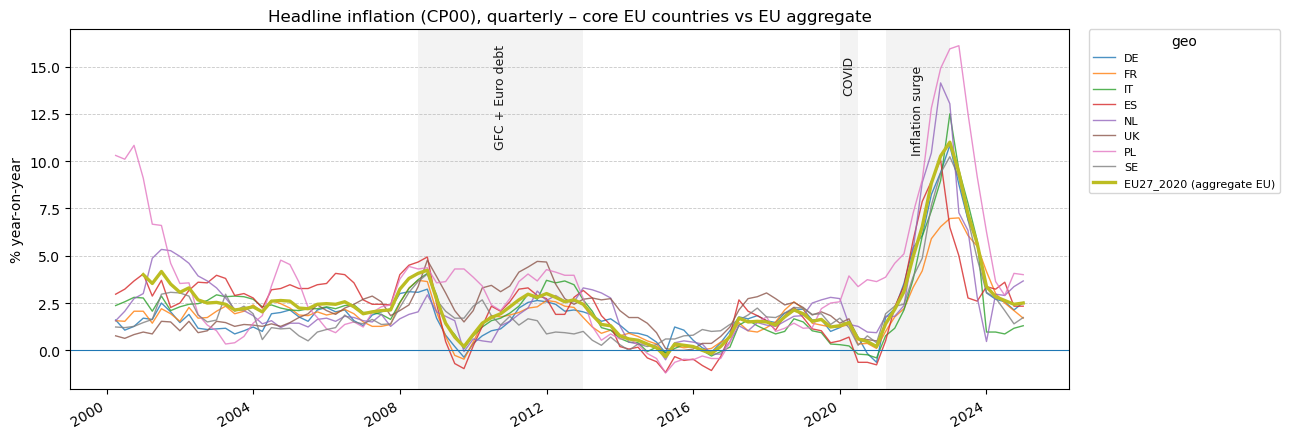

In [11]:
# 2.3 Time series – headline inflation for core countries vs EU aggregate

plot_data = macro_geo[macro_geo["geo"].isin(PLOT_GEOS)].copy()
plot_data = plot_data.sort_values(["geo", "timeQuarter"])
plot_data["time_dt"] = plot_data["timeQuarter"].dt.to_timestamp(how="end")

fig, ax = plt.subplots(figsize=(13, 4.5))

# Thin lines for individual core countries
for geo in CORE_GEOS:
    sub = plot_data[plot_data["geo"] == geo]
    ax.plot(
        sub["time_dt"],
        sub["hicpInflation"],
        linewidth=1.0,
        alpha=0.8,
        label=geo,
    )

# Thicker line for EU aggregate on top
sub_eu = plot_data[plot_data["geo"] == AGG_GEO]
ax.plot(
    sub_eu["time_dt"],
    sub_eu["hicpInflation"],
    linewidth=2.4,
    label=f"{AGG_GEO} (aggregate EU)",
)

# Optional: crisis shading if CRISIS_WINDOWS_MAIN is defined
if "CRISIS_WINDOWS_MAIN" in globals():
    ymin, ymax = ax.get_ylim()
    y_range = ymax - ymin
    for i, (label, (start_q, end_q)) in enumerate(CRISIS_WINDOWS_MAIN.items()):
        start_ts = pd.Period(start_q, freq="Q-DEC").to_timestamp(how="start")
        end_ts = pd.Period(end_q, freq="Q-DEC").to_timestamp(how="end")

        ax.axvspan(start_ts, end_ts, color="lightgrey", alpha=0.25, linewidth=0)

        x_mid = start_ts + (end_ts - start_ts) / 2
        y_pos = ymax - (0.04 + 0.03 * i) * y_range
        ax.text(
            x_mid,
            y_pos,
            label,
            ha="center",
            va="top",
            fontsize=9,
            rotation=90,
            alpha=0.9,
        )

ax.set_title("Headline inflation (CP00), quarterly – core EU countries vs EU aggregate")
ax.set_ylabel("% year-on-year")
ax.axhline(0, linewidth=0.8)

# Grid
ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.7)

# X-axis: show yearly ticks (every 4 years labelled)
import matplotlib.dates as mdates

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

# Legend outside right
ax.legend(
    title="geo",
    fontsize=8,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()

fig_path = FIGURES_DIR / "macro_inflation_core_vs_eu_aggregate_refined.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved inflation figure to:", fig_path)
plt.show()


Saved employment figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/macro_employment_core_vs_eu_aggregate_refined.png


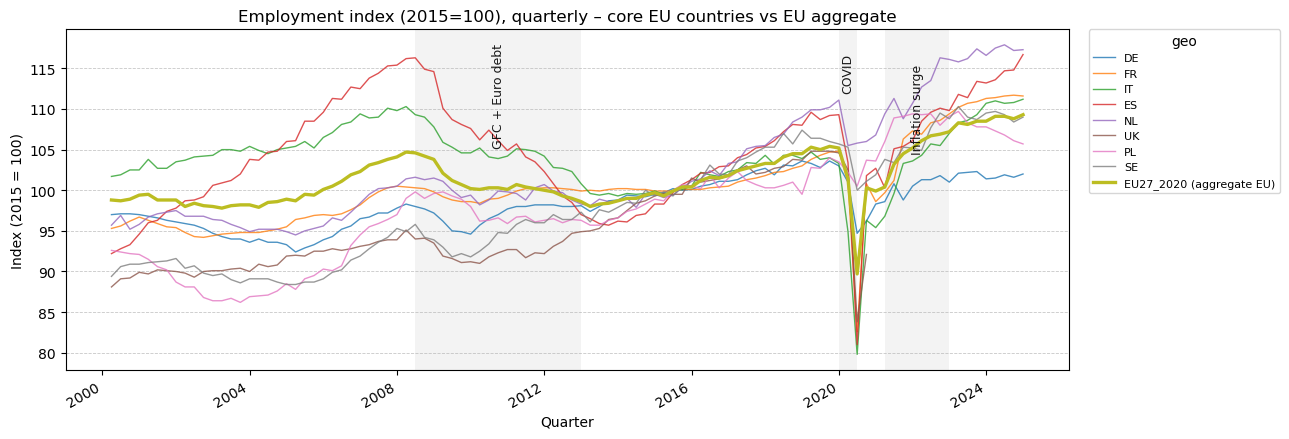

In [12]:
# 2.4 Time series – employment for core countries vs EU aggregate

fig, ax = plt.subplots(figsize=(13, 4.5))

for geo in CORE_GEOS:
    sub = plot_data[plot_data["geo"] == geo]
    ax.plot(
        sub["time_dt"],
        sub["employmentIndex"],
        linewidth=1.0,
        alpha=0.8,
        label=geo,
    )

sub_eu = plot_data[plot_data["geo"] == AGG_GEO]
ax.plot(
    sub_eu["time_dt"],
    sub_eu["employmentIndex"],
    linewidth=2.4,
    label=f"{AGG_GEO} (aggregate EU)",
)

# Optional: crisis shading, reusing same windows
if "CRISIS_WINDOWS_MAIN" in globals():
    ymin, ymax = ax.get_ylim()
    y_range = ymax - ymin
    for i, (label, (start_q, end_q)) in enumerate(CRISIS_WINDOWS_MAIN.items()):
        start_ts = pd.Period(start_q, freq="Q-DEC").to_timestamp(how="start")
        end_ts = pd.Period(end_q, freq="Q-DEC").to_timestamp(how="end")

        ax.axvspan(start_ts, end_ts, color="lightgrey", alpha=0.25, linewidth=0)

        x_mid = start_ts + (end_ts - start_ts) / 2
        y_pos = ymax - (0.04 + 0.03 * i) * y_range
        ax.text(
            x_mid,
            y_pos,
            label,
            ha="center",
            va="top",
            fontsize=9,
            rotation=90,
            alpha=0.9,
        )

ax.set_title("Employment index (2015=100), quarterly – core EU countries vs EU aggregate")
ax.set_ylabel("Index (2015 = 100)")
ax.set_xlabel("Quarter")

ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.7)

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

ax.legend(
    title="geo",
    fontsize=8,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()

fig_path = FIGURES_DIR / "macro_employment_core_vs_eu_aggregate_refined.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved employment figure to:", fig_path)
plt.show()


In [13]:
summary = (
    macro_geo
    .groupby("geo")[["hicpInflation", "employmentIndex"]]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

summary["geo_name"] = summary["geo"].map(geo_name_map)
summary = summary.set_index("geo")  # keep code as index but show name as column

# show core countries + EU aggregate
summary.loc[CORE_GEOS + [AGG_GEO]]


hicpInflation                                employmentIndex                                                          geo_name
                   mean       std       min        max            mean       std   min    max                                           
geo                                                                                                                                     
DE             2.058333  1.916708 -0.633333  10.833333          98.281  2.984766  92.4  103.6                                    Germany
FR                1.922  1.453756 -0.466667        7.0         100.284  4.860659  82.6  111.7                                     France
IT             2.145667  2.089988      -0.4       12.5         103.956  4.268591  79.8  111.2                                      Italy
ES                2.379  2.023036 -1.166667  10.066667         104.779  6.677647  81.0  116.7                                      Spain
NL             2.437333  2.387628      -0.5  14.133333         102.388  6.696212  94.5  117.9                                Netherlands
UK              1.98373  1.110067       0.0   4.766667        94.86747  5.035244  83.8  104.8                             United Kingdom
PL             3.515333  3.536944      -1.2       16.1          97.735  6.581799  86.2  109.7                                     Poland
SE             2.008333   1.82159       0.0  10.233333          97.794  6.865767  88.4  110.3                                     Sweden
EU27_2020      2.451203  2.048764 -0.333333       11.0         101.551    3.4069  89.7  109.3  European Union - 27 countries (from 2020)

### 3. Q1 – Crises in inflation and employment

**Question**  “How do major crises show up in inflation and employment, and how heterogeneous are they across EU countries?”

In the next steps I focus on how major macro crises show up in headline inflation (CP00) and total employment.  
I start with a narrow view (Germany vs the EU aggregate) and will later zoom out to core countries and then all 36 geos.

***3.1 Germany vs EU27_2020***

Here I compare Germany with the EU27_2020 aggregate.  
The goal is to see whether Germany behaves like a “typical” EU country over time, and how the main crises show up in inflation and employment.



In [14]:
# 3.1.1 Extract Germany and EU aggregate series

AGG_GEO = "EU27_2020"

macro_de_eu = macro_geo[macro_geo["geo"].isin(["DE", AGG_GEO])].copy()
macro_de_eu = macro_de_eu.sort_values(["geo", "timeQuarter"])

# Use a datetime representation for clean plotting and shading
macro_de_eu["time_dt"] = macro_de_eu["timeQuarter"].dt.to_timestamp(how="end")

macro_de_eu.head()


,geo,timeQuarter,hicpInflation,hicpIndex,employmentIndex,time_dt
600,DE,2000Q1,1.6,78.566667,97.0,2000-03-31 23:59:59.999999999
601,DE,2000Q2,1.066667,78.633333,97.1,2000-06-30 23:59:59.999999999
602,DE,2000Q3,1.266667,79.133333,97.1,2000-09-30 23:59:59.999999999
603,DE,2000Q4,1.7,79.4,97.0,2000-12-31 23:59:59.999999999
604,DE,2001Q1,1.633333,79.833333,96.8,2001-03-31 23:59:59.999999999


In [15]:
# 3.1.2 Helper function to shade the crisis windows on a matplotlib axis

def plot_de_vs_eu(
    df,
    value_col,
    ylabel,
    title,
    filename,
    crisis_windows=CRISIS_WINDOWS_MAIN,
):
    fig, ax = plt.subplots(figsize=(11, 4))

    de = df[df["geo"] == "DE"]
    eu = df[df["geo"] == AGG_GEO]

    line_de, = ax.plot(
        de["time_dt"],
        de[value_col],
        linewidth=2.0,
        label="Germany",
    )
    line_eu, = ax.plot(
        eu["time_dt"],
        eu[value_col],
        color="red",
        linewidth=2.3,
        label="EU27_2020 (EU aggregate)",
    )

    ymin, ymax = ax.get_ylim()
    y_range = ymax - ymin

    # Shade crisis periods
    for i, (label, (start_q, end_q)) in enumerate(crisis_windows.items()):
        start_ts = pd.Period(start_q, freq="Q-DEC").to_timestamp(how="start")
        end_ts = pd.Period(end_q, freq="Q-DEC").to_timestamp(how="end")

        ax.axvspan(start_ts, end_ts, color="lightgrey", alpha=0.25, linewidth=0)

        x_mid = start_ts + (end_ts - start_ts) / 2
        # stagger labels a bit vertically to avoid collision
        y_pos = ymax - (0.04 + 0.03 * i) * y_range

        ax.text(
            x_mid,
            y_pos,
            label,
            ha="center",
            va="top",
            fontsize=9,
            rotation=90,
            alpha=0.85,
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if value_col != "hicpInflation":
        ax.set_xlabel("Quarter")

    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
    fig.autofmt_xdate()

    crisis_patch = mpatches.Patch(
    facecolor="lightgrey",
    alpha=0.25,
    label="Crisis periods",
    )
    handles = [line_de, line_eu, crisis_patch]
    labels = [h.get_label() for h in handles]

    ax.legend(
    handles,
    labels,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=9,
    frameon=True,
    title="Series",
    )


    plt.tight_layout()
    fig_path = FIGURES_DIR / filename
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved figure to:", fig_path)
    plt.show()



Saved figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/macro_inflation_DE_vs_EU27_crises_clean.png


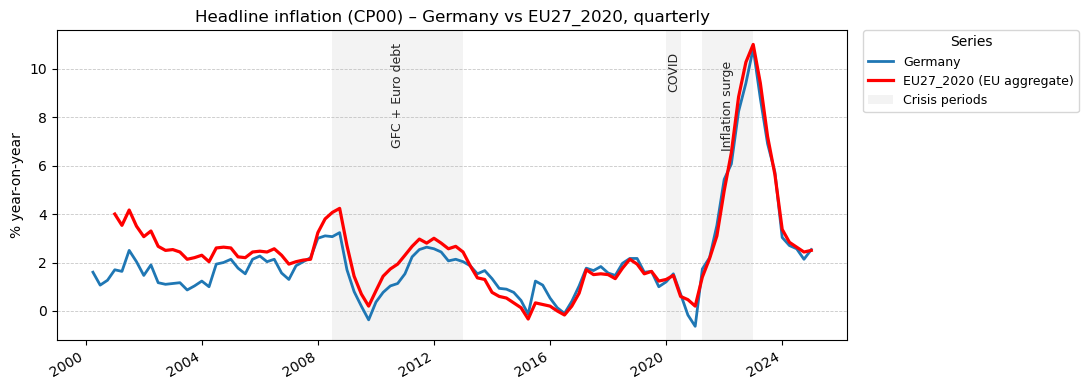

In [16]:
# 3.1.3 Headline inflation – Germany vs EU27_2020 with crisis shading
plot_de_vs_eu(
    df=macro_de_eu,
    value_col="hicpInflation",
    ylabel="% year-on-year",
    title="Headline inflation (CP00) – Germany vs EU27_2020, quarterly",
    filename="macro_inflation_DE_vs_EU27_crises_clean.png",
)



**What I see in headline inflation (Germany vs EU)**

The pattern around the three crises is very consistent with standard macro channels:

- **2008–2012 (GFC + Euro debt)**  
  The collapse in demand during the financial crisis and the following euro area debt problems pushed inflation down. Banks were in repair mode, firms cut investment, households deleveraged, and fiscal policy turned restrictive after 2010. Energy prices also fell sharply in 2008–2009. All of that shows up as a disinflation episode and a brief flirt with negative inflation around 2009–2010. The rebound afterwards is visible but not very strong, because the recovery itself was slow and fragmented across the euro area.

- **Post-crisis “low inflation” regime (roughly 2013–2019)**  
  After the euro crisis the economy was expanding again, but with a lot of slack in labour markets and still-weak wage growth. The ECB kept policy rates at or below zero and ran QE, yet inflation stubbornly stayed below the 2% target. This is exactly what the flat section of the plot shows: small fluctuations around 1–2% for both Germany and the EU aggregate.

- **COVID shock and the 2021–2022 surge**  
  In 2020 the first lockdown wave crushed mobility, services demand and oil prices, so inflation briefly drops again. The sharp surge from 2021 onwards is the mirror image: reopening, supply bottlenecks, huge fiscal support, very fast recovery in goods demand, and then the energy and food price shock linked to the Russia–Ukraine war. These forces hit the whole EU, which is why Germany and the EU27 aggregate almost sit on top of each other during the spike. The decline after the peak reflects falling energy prices and tighter monetary policy working through, but the level is still well above the pre-COVID “low inflation” regime at the end of the sample.


Saved figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/macro_employment_DE_vs_EU27_crises_clean.png


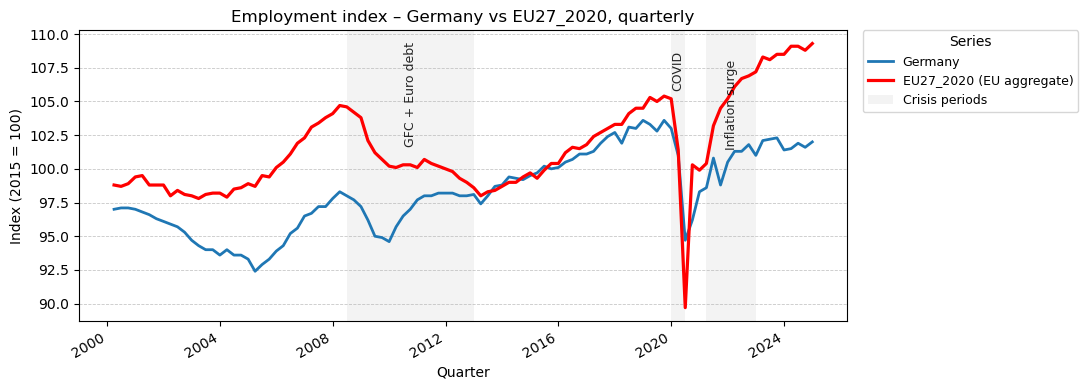

In [17]:
# 3.1.4 Employment index – Germany vs EU27_2020 with crisis shading

plot_de_vs_eu(
    df=macro_de_eu,
    value_col="employmentIndex",
    ylabel="Index (2015 = 100)",
    title="Employment index – Germany vs EU27_2020, quarterly",
    filename="macro_employment_DE_vs_EU27_crises_clean.png",
)


**What I see in employment (Germany vs EU)**

The employment index helps explain why inflation behaves in this way.

- **Pre-crisis and GFC + Euro debt period**  
  EU employment rises strongly up to 2008 and then falls quite sharply, especially in countries with housing booms and weak banks. Germany, by contrast, shows only a mild dip in 2009 and then a relatively quick recovery. This “German labour market resilience” is consistent with labour-hoarding, strong export demand after 2010, and the use of short-time work schemes. The euro area as a whole carried much more labour market slack for a longer time, contributing to the subdued inflation after 2010.

- **2013–2019 recovery**  
  Both Germany and the EU see steady employment growth, but the EU needs this just to re-absorb the big losses from the earlier crises. The combination of still-high unemployment in some countries and moderate wage growth helps to keep the 2013–2019 inflation regime low and stable.

- **COVID shock and recovery**  
  The vertical drop in 2020 is the mechanical effect of lockdowns. Germany and the EU both bounce back quickly, helped by job-retention schemes, massive fiscal support, and very loose monetary policy. The rapid employment recovery, together with very strong demand for goods and services, is part of the reason why the inflation surge in 2021–2022 does not fade immediately: the labour market tightens instead of remaining in crisis mode.

In short, the plots tell a coherent story: deep crises (GFC, euro debt, COVID) first create slack and push inflation down, but once policy support and reopening kick in, the combination of recovering employment, bottlenecks and energy shocks can generate the kind of strong inflation rebound we see after COVID.



In [18]:
# 3.2.1 Core countries + EU aggregate

CORE_GEOS = ["DE", "FR", "IT", "ES", "NL", "UK", "PL", "SE"]
AGG_GEO = "EU27_2020"  # already used above, just restating intent

core_plus_agg = CORE_GEOS + [AGG_GEO]

macro_core_eu = macro_geo[macro_geo["geo"].isin(core_plus_agg)].copy()
macro_core_eu = macro_core_eu.sort_values(["geo", "timeQuarter"])

# Ensure datetime column exists
if "time_dt" not in macro_core_eu.columns:
    macro_core_eu["time_dt"] = macro_core_eu["timeQuarter"].dt.to_timestamp(how="end")

macro_core_eu["geo"].value_counts()


geo
DE           100
ES           100
EU27_2020    100
FR           100
IT           100
NL           100
PL           100
SE           100
UK           100
Name: count, dtype: int64

In [19]:
def plot_country_vs_eu_panel(ax, df, geo, value_col, crisis_windows=CRISIS_WINDOWS_MAIN):
    sub = df[df["geo"].isin([geo, AGG_GEO])].copy()
    sub = sub.sort_values(["geo", "timeQuarter"])

    # ensure datetime
    if "time_dt" not in sub.columns:
        sub["time_dt"] = sub["timeQuarter"].dt.to_timestamp(how="end")

    country = sub[sub["geo"] == geo]
    eu = sub[sub["geo"] == AGG_GEO]

    # EU as thin grey background
    ax.plot(
        eu["time_dt"],
        eu[value_col],
        color="0.7",
        linewidth=1.0,
        label="EU27_2020",
        zorder=1,
    )
    # country highlighted
    ax.plot(
        country["time_dt"],
        country[value_col],
        linewidth=1.8,
        label=geo,
        zorder=2,
    )

    # crisis shading
    ymin, ymax = ax.get_ylim()
    y_range = ymax - ymin
    for i, (label, (start_q, end_q)) in enumerate(crisis_windows.items()):
        start_ts = pd.Period(start_q, freq="Q-DEC").to_timestamp(how="start")
        end_ts = pd.Period(end_q, freq="Q-DEC").to_timestamp(how="end")

        ax.axvspan(start_ts, end_ts, color="lightgrey", alpha=0.18, linewidth=0)

        # only label crises once per column (or skip labels entirely in these panels to reduce clutter)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

    ax.set_title(geo, fontsize=9)


Saved panel figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/macro_inflation_core_panels_vs_eu.png


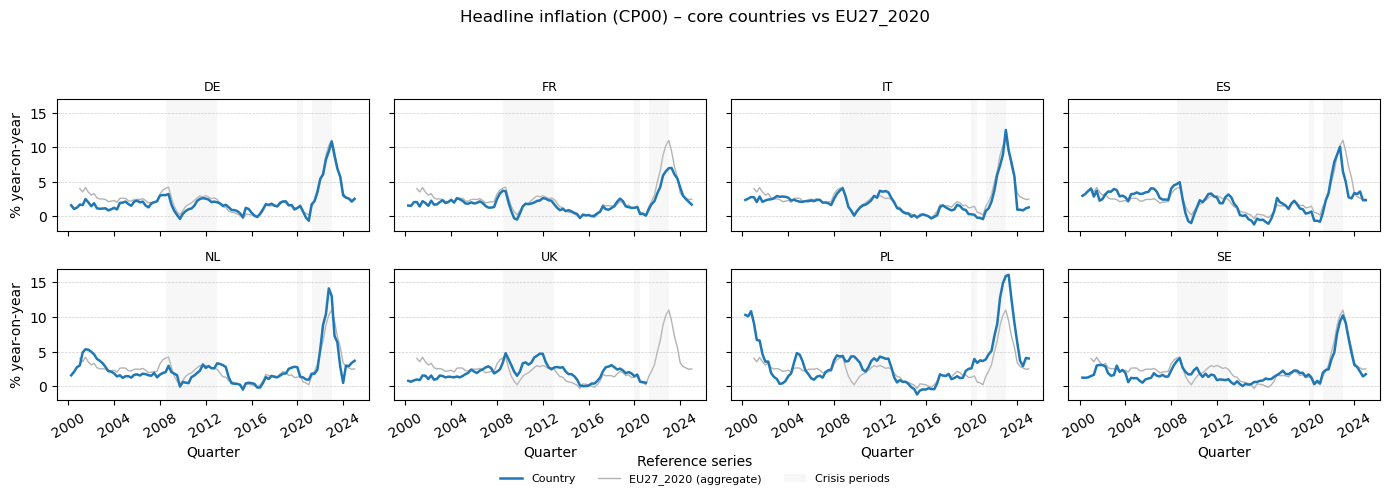

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(14, 5), sharex=True, sharey=True)

for ax, geo in zip(axes.ravel(), CORE_GEOS):
    plot_country_vs_eu_panel(
        ax=ax,
        df=macro_core_eu,
        geo=geo,
        value_col="hicpInflation",
    )

# Title slightly down from absolute top
fig.suptitle(
    "Headline inflation (CP00) – core countries vs EU27_2020",
    fontsize=12,
    y=0.98,
)

# bottom row x-labels
for ax in axes[-1, :]:
    ax.set_xlabel("Quarter")

# left column y-labels
axes[0, 0].set_ylabel("% year-on-year")
axes[1, 0].set_ylabel("% year-on-year")

# tick rotation for readability
for ax in axes.ravel():
    ax.tick_params(axis="x", rotation=30)

# Figure-level legend at the bottom
handles = [
    Line2D([0], [0], color="C0", linewidth=1.8, label="Country"),
    Line2D([0], [0], color="0.7", linewidth=1.0,
           label="EU27_2020 (aggregate)"),
    Patch(facecolor="lightgrey", alpha=0.18, label="Crisis periods"),
]

fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    frameon=False,
    fontsize=8,
    title="Reference series",
)

# leave room at top for title and at bottom for legend
fig.tight_layout(rect=[0, 0.05, 1, 0.93])

fig_path = FIGURES_DIR / "macro_inflation_core_panels_vs_eu.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved panel figure to:", fig_path)
plt.show()


**3.2 Core EU countries – headline inflation relative to EU27_2020**

In this panel I compare headline inflation (CP00) in the eight core countries (DE, FR, IT, ES, NL, UK, PL, SE) with the EU27_2020 aggregate, shown as a thin grey reference line. The shaded areas mark the three main crisis windows (GFC + Euro debt, COVID, and the recent inflation surge).

A few patterns stand out:

- **Pre-2008:** Most countries track the EU aggregate quite closely with inflation mostly between 1–3% y/y. Spain and the Netherlands run slightly above the EU average, while Germany is modestly below.
- **GFC + Euro-area debt crisis (2008–2012):** All countries show the sharp disinflation and brief deflation in 2009, followed by a temporary rebound around 2010–2011. The EU aggregate captures this well; Italy and the Netherlands overshoot the EU line during the rebound, while Germany stays close to the average.
- **2013–2019 low-inflation period:** Inflation is persistently low and very similar across countries, with only small, short-lived deviations. The EU aggregate is a good summary of national paths in this phase.
- **COVID shock (2020):** Inflation drops almost everywhere but the decline is fairly short-lived and heterogeneous. The UK and Poland show slightly different timing and depth compared to the EU27_2020 line, hinting at national policy and exchange-rate effects.
- **Inflation surge (2021–2022):** All countries experience a steep rise in inflation, but the **level and timing differ**:
  - The spike is especially pronounced in **NL, PL and SE**, where inflation clearly exceeds the EU average.
  - Germany, France and Italy follow the EU pattern more closely, with peaks only slightly above the aggregate.
- **2023–2024 disinflation:** Inflation falls back but remains above 2% in most countries. The convergence towards the EU line suggests that the common energy and monetary policy shock is fading, while some cross-country differences in persistence remain.
- The UK panel stops after 2020, because my Eurostat macro data only report HICP inflation for the UK up to the Brexit transition period. This is a data-coverage issue rather than an economic statement – I’m not truncating the series by choice.

Overall, these small multiples confirm that the EU27_2020 aggregate is a reasonable benchmark for “core Europe”, but they also highlight important outliers (notably NL and PL during the inflation surge) that I need to keep in mind when I later move to cross-country modelling.


Saved panel figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/macro_employment_core_panels_vs_eu.png


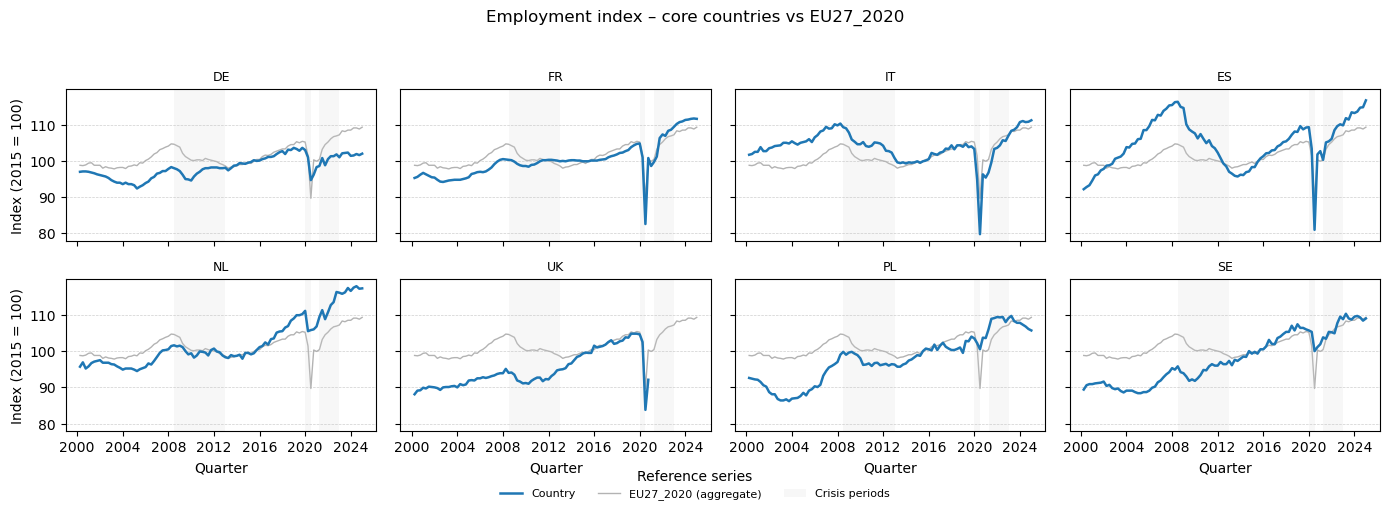

In [21]:
# Small multiples for core employment vs EU
fig, axes = plt.subplots(2, 4, figsize=(14, 5), sharex=True, sharey=True)

for ax, geo in zip(axes.ravel(), CORE_GEOS):
    plot_country_vs_eu_panel(
        ax=ax,
        df=macro_core_eu,
        geo=geo,
        value_col="employmentIndex",
    )

fig.suptitle("Employment index – core countries vs EU27_2020", fontsize=12)

for ax in axes[-1, :]:
    ax.set_xlabel("Quarter")
axes[0, 0].set_ylabel("Index (2015 = 100)")
axes[1, 0].set_ylabel("Index (2015 = 100)")

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

handles = [
    Line2D([0], [0], color="C0", linewidth=1.8, label="Country"),
    Line2D([0], [0], color="0.7", linewidth=1.0, label="EU27_2020 (aggregate)"),
    Patch(facecolor="lightgrey", alpha=0.18, label="Crisis periods"),
]

fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False,
    fontsize=8,
    title="Reference series",
)

fig.tight_layout(rect=[0, 0.02, 1, 0.95])

fig_path = FIGURES_DIR / "macro_employment_core_panels_vs_eu.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved panel figure to:", fig_path)
plt.show()


 **3.2.3 Employment – core countries vs EU27_2020**

In this figure I compare employment dynamics in the eight core countries with the EU27_2020 aggregate. The bold blue line shows each country’s employment index (2015 = 100), while the thin grey line is the EU aggregate plotted in the background, and shaded bands mark the main crisis periods (GFC + Euro debt, COVID, inflation surge).

Overall, employment follows a broadly similar trend across the core economies, but there are clear differences in depth and speed of adjustment. Southern Europe (IT, ES) shows a much stronger pre-2008 expansion and a noticeably weaker labour-market recovery during the Euro-area debt crisis, whereas countries like DE and NL display more moderate swings and relatively stable post-2013 growth. During the COVID shock, all countries exhibit a sharp but short-lived drop followed by a strong rebound, with FR and PL overshooting the EU aggregate in the subsequent recovery. The UK again diverges slightly from the EU path after 2020, consistent with both the COVID shock and the post-Brexit realignment of its labour market.


**3.3 All 36 countries – cross-country patterns over crises**

In this subsection I finally use the full panel of 36 geos instead of only Germany and the core group.  
The goal is to understand **how broad-based each crisis was** and where Germany sits in the wider European distribution.

I focus on:

- cross-country patterns in **headline inflation (CP00)** and **employment** over time,
- how much **dispersion** there is across countries in “normal” times versus the GFC/Euro debt crisis, COVID and the recent inflation surge,
- which countries systematically run **above or below the EU aggregate**,
- and whether Germany behaves like a “typical” EU country once I consider all 36 geos.

I only use inflation and employment here. The income variable has substantial missing data before 2010, so I keep income for later sections where I restrict the sample to better-covered years.


In [22]:
# --- 3.3 Deviations from EU aggregate across all 36 geos ---
from src.config import GEO_LIST_36
# ensure timeQuarter is a PeriodIndex
assert str(macro_geo["timeQuarter"].dtype).startswith("period[")

# keep only geos we care about (your GEO_LIST_36)
macro_all = macro_geo[macro_geo["geo"].isin(GEO_LIST_36)].copy()

# attach EU27_2020 series by timeQuarter
eu = macro_geo[macro_geo["geo"] == AGG_GEO].set_index("timeQuarter")

macro_all = macro_all.join(
    eu[["hicpInflation", "employmentIndex"]]
      .rename(columns={
          "hicpInflation": "hicpInflation_eu",
          "employmentIndex": "employmentIndex_eu",
      }),
    on="timeQuarter",
)

# deviations (country – EU)
macro_all["dev_infl"] = macro_all["hicpInflation"] - macro_all["hicpInflation_eu"]
macro_all["dev_empl"] = macro_all["employmentIndex"] - macro_all["employmentIndex_eu"]


In [23]:
# 3.3.2 Aggregate by crisis window
def crisis_avg(df, value_col):
    """
    Returns a DataFrame: index = geo, columns = crises,
    values = mean deviation in that crisis window.
    """
    out = {}
    for crisis, (start_q, end_q) in CRISIS_WINDOWS_MAIN.items():
        start = pd.Period(start_q, freq="Q-DEC")
        end   = pd.Period(end_q,   freq="Q-DEC")
        mask = (df["timeQuarter"] >= start) & (df["timeQuarter"] <= end)
        tmp = (
            df.loc[mask]
              .groupby("geo")[value_col]
              .mean()
        )
        out[crisis] = tmp
    result = pd.DataFrame(out)

    # optional: sort rows by average across crises (most "above EU" at top)
    result["mean_abs"] = result.abs().mean(axis=1)
    result = result.sort_values("mean_abs", ascending=False).drop(columns="mean_abs")
    return result

infl_crisis = crisis_avg(macro_all, "dev_infl")
empl_crisis = crisis_avg(macro_all, "dev_empl")


In [24]:
# Helper

CORE_GEOS = ["DE", "FR", "IT", "ES", "NL", "UK", "PL", "SE"]
AGG_GEO = "EU27_2020"   # EU aggregate we use as baseline


def geo_color(geo: str) -> str:
    """
    Map each geo code to a colour:

    - Germany (DE): blue
    - Other core countries: orange
    - EU27_2020 aggregate: green (same as zero line)
    - Everyone else: light grey
    """
    if geo == "DE":
        return "tab:blue"          # highlight Germany
    elif geo == AGG_GEO:
        return "black"         # EU27_2020 aggregate (baseline)
    elif geo in CORE_GEOS:
        return "tab:orange"        # other core countries
    else:
        return "0.7"               # other EU / EEA



In [25]:
def plot_crisis_bars_shared_y(
    dev_df,
    title: str,
    xlabel: str,
    filename: str,
    sort_by: str | None = None,
):
    """
    Plot deviations from EU27_2020 for several crisis windows as
    side-by-side horizontal bar charts with a **shared y-axis**.

    Parameters
    ----------
    dev_df : pandas.DataFrame
        Index: geo codes (e.g. 'DE', 'FR', ... , 'EU27_2020')
        Columns: crisis windows (e.g. ['GFC + Euro debt', 'COVID', 'Inflation surge'])
        Values: deviation vs EU27_2020 for that crisis (in same units as xlabel).
    title : str
        Overall figure title.
    xlabel : str
        Label for the x-axis (used on all subplots).
    filename : str
        File name (under FIGURES_DIR) to save the figure.
    sort_by : str or None
        If given and matches a column name, countries are ordered by that column.
        Otherwise we order by the row mean across crises.
    """

    crises = list(dev_df.columns)

    # ---- choose a single order for countries (shared y-axis) ----
    if sort_by is not None and sort_by in crises:
        order = dev_df[sort_by].sort_values().index
    else:
        order = dev_df.mean(axis=1).sort_values().index

    dev_df = dev_df.loc[order]

    geos = dev_df.index.to_list()
    y_pos = np.arange(len(geos))

    # ---- set up subplots ----
    fig, axes = plt.subplots(
        1, len(crises),
        figsize=(12, 14),   # tall & readable; tweak if you want
        sharey=True,
    )
    if len(crises) == 1:
        axes = [axes]

    for ax, crisis in zip(axes, crises):
        vals = dev_df[crisis].to_numpy()
        colors = [geo_color(g) for g in geos]

        # bars
        ax.barh(y_pos, vals, color=colors, edgecolor="none")

        # EU27_2020 baseline at 0 — same colour as EU27_2020 bar
        ax.axvline(0, color="black", linewidth=0.7, linestyle="--")


        # light x-grid for easier reading
        ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.4)

        ax.set_title(crisis, fontsize=11)
        ax.set_xlabel(xlabel)

        # ---- shared y-axis: same labels on every panel ----
        ax.set_yticks(y_pos)
        ax.set_yticklabels(geos, fontsize=8)

        # only left subplot gets explicit y-label text
        if ax is axes[0]:
            ax.set_ylabel("Country")
        else:
            ax.set_ylabel("")

    # ---- legend: explain colours once for whole figure ----
    legend_handles = [
    Patch(color="tab:blue",   label="Germany (DE)"),
    Patch(color="tab:orange", label="Other core countries"),
    Patch(color="black",      label="EU27_2020 (aggregate / zero line)"),
    Patch(color="0.7",        label="Other EU / EEA"),
    ]
    fig.legend(
        handles=legend_handles,
        title="Highlight",
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),   # a bit above the plot area
        frameon=False,
        fontsize=9,
        title_fontsize=10,
    )

    # leave enough room at the top for legend + title
    fig.suptitle(title, y=0.96, fontsize=12)
    fig.tight_layout(rect=[0, 0.03, 1, 0.90])

    fig_path = FIGURES_DIR / filename
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved figure to:", fig_path)
    plt.show()


Saved figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/macro_inflation_crisis_bars_shared_y.png


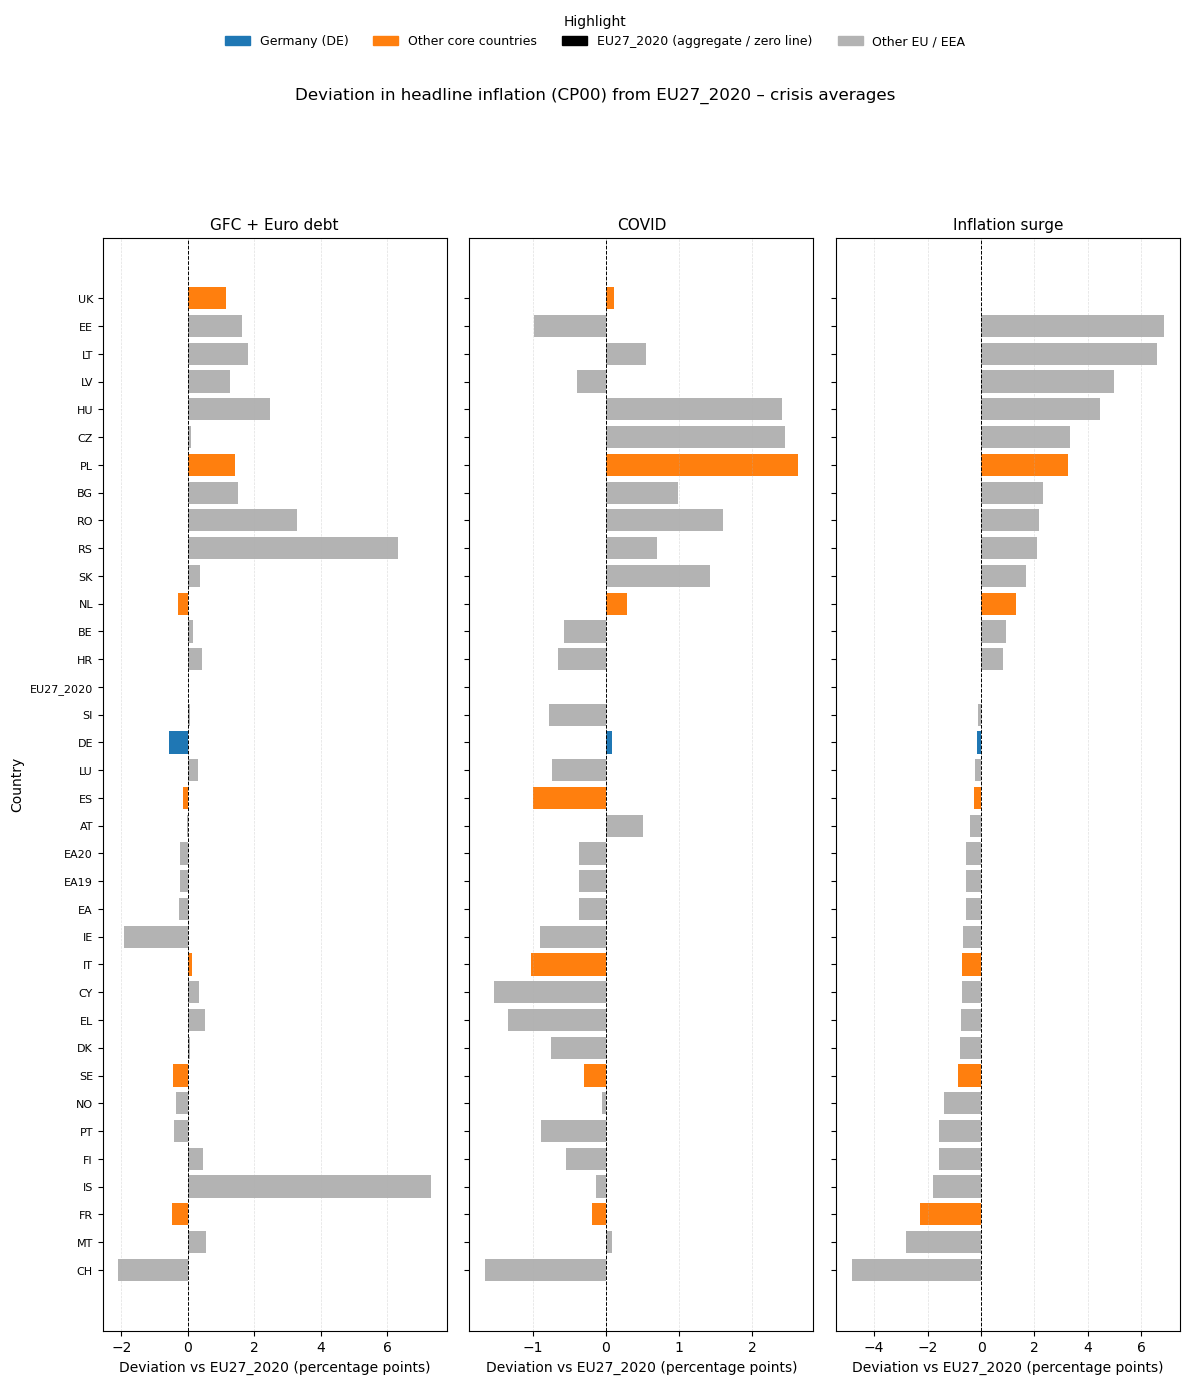

In [26]:
# Inflation deviations vs EU27_2020 during each crisis
plot_crisis_bars_shared_y(
    infl_crisis,
    title="Deviation in headline inflation (CP00) from EU27_2020 – crisis averages",
    xlabel="Deviation vs EU27_2020 (percentage points)",
    filename="macro_inflation_crisis_bars_shared_y.png",
    sort_by="Inflation surge",    # or None / any crisis column
)



**3.3.A Deviations in headline inflation (CP00) from EU27_2020 – crisis averages**  

How to read the figure (quick guide)

- The chart has **three panels**, one per crisis:
  - **Left:** Global Financial Crisis + Euro-area sovereign debt crisis  
  - **Middle:** COVID shock  
  - **Right:** 2021–23 inflation surge  
- The **x-axis** shows:  
  > average inflation in the country during that crisis  
  > **minus** average inflation of **EU27_2020**

  - Bars **to the right of the dashed vertical line (0)** → inflation **higher** than the EU27_2020 average.  
  - Bars **to the left** → inflation **lower** than the EU27_2020 average.
- **Colours**:
  - **Blue** – Germany (DE)  
  - **Orange** – other core countries (FR, IT, ES, NL, UK, PL, SE)  
  - **Grey** – other EU / EEA economies  
  - **Black dashed vertical line** – EU27_2020 benchmark (always 0 by construction)
- Within each panel, countries are **sorted by their deviation** in that crisis. Top bars = largest overshoots vs EU; bottom bars = largest undershoots.

So the figure answers a very narrow question:  
> *In each crisis, which countries ran systematically higher or lower inflation than the EU average, and by how many percentage points?*


**Economic interpretation**

- **GFC + Euro-debt crisis (left panel)**  
  - Dispersion around the EU average is **moderate** (mostly within ±2pp).  
  - Several **CEE and Baltic economies** (PL, LV, LT, EE, BG/RO) sit clearly **above zero** → they had **persistently higher inflation** than the EU benchmark even in a downturn, consistent with **catch-up / Balassa–Samuelson** effects and fast nominal convergence.  
  - Germany’s bar is around zero or slightly negative, matching the narrative of **subdued German inflation in the 2010s** (wage moderation, strong competitiveness, conservative inflation culture).  
  - Some crisis-hit Southern economies lie slightly below zero, reflecting **internal devaluation and weak demand** after the debt crisis rather than overheating.

- **COVID shock (middle panel)**  
  - Cross-country differences remain **small**; most bars are within ±1–1.5pp.  
  - Poland is a clear **positive outlier**, with inflation well **above** EU27_2020 → driven by **strong post-lockdown demand, looser policies and pre-existing inflation momentum**.  
  - Several economies show small **negative deviations**, indicating **stronger disinflation** than the EU average where lockdowns were tighter or tourism collapsed.  
  - Germany is again very close to zero → in price dynamics it behaves like a **“typical” euro-area country** during COVID, not a special case.

- **Inflation surge 2021–23 (right panel)**  
  - Here **dispersion explodes**: large positive deviations for Baltic and several CEE countries (LV, LT, EE, PL, etc.). They experienced **much higher inflation** than the EU aggregate, reflecting:
    - higher **energy intensity** and exposure to Russian gas,  
    - rapid **wage and demand catch-up** after COVID,  
    - more limited use of **price shields or regulated tariffs**.  
  - Germany is moderately above the EU average; France is near or slightly below → consistent with **French energy price caps** versus Germany’s more direct price adjustment.  
  - The fact that many of the **same countries with above-average inflation pre-crisis** reappear at the top suggests **structural differences in inflation regimes**, not just one-off energy shocks.

- **Big picture from the inflation chart**  
  - Earlier crises mainly shifted the **level** of inflation in Europe; **cross-country dispersion remained contained**.  
  - The post-COVID inflation surge is different: dispersion widens sharply and becomes **highly skewed towards CEE/Baltics**.  
  - Germany looks like a **reference economy** rather than an outlier: slightly below average in the 2010s, roughly average in COVID, only moderately above average in the surge.  
  - For later modelling, this supports:
    - including **country fixed effects in inflation**, and  
    - allowing **crisis-specific shocks to interact with country characteristics** (energy mix, wage indexation, exchange-rate regime, etc.).


Saved figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/macro_employment_crisis_bars_shared_y.png


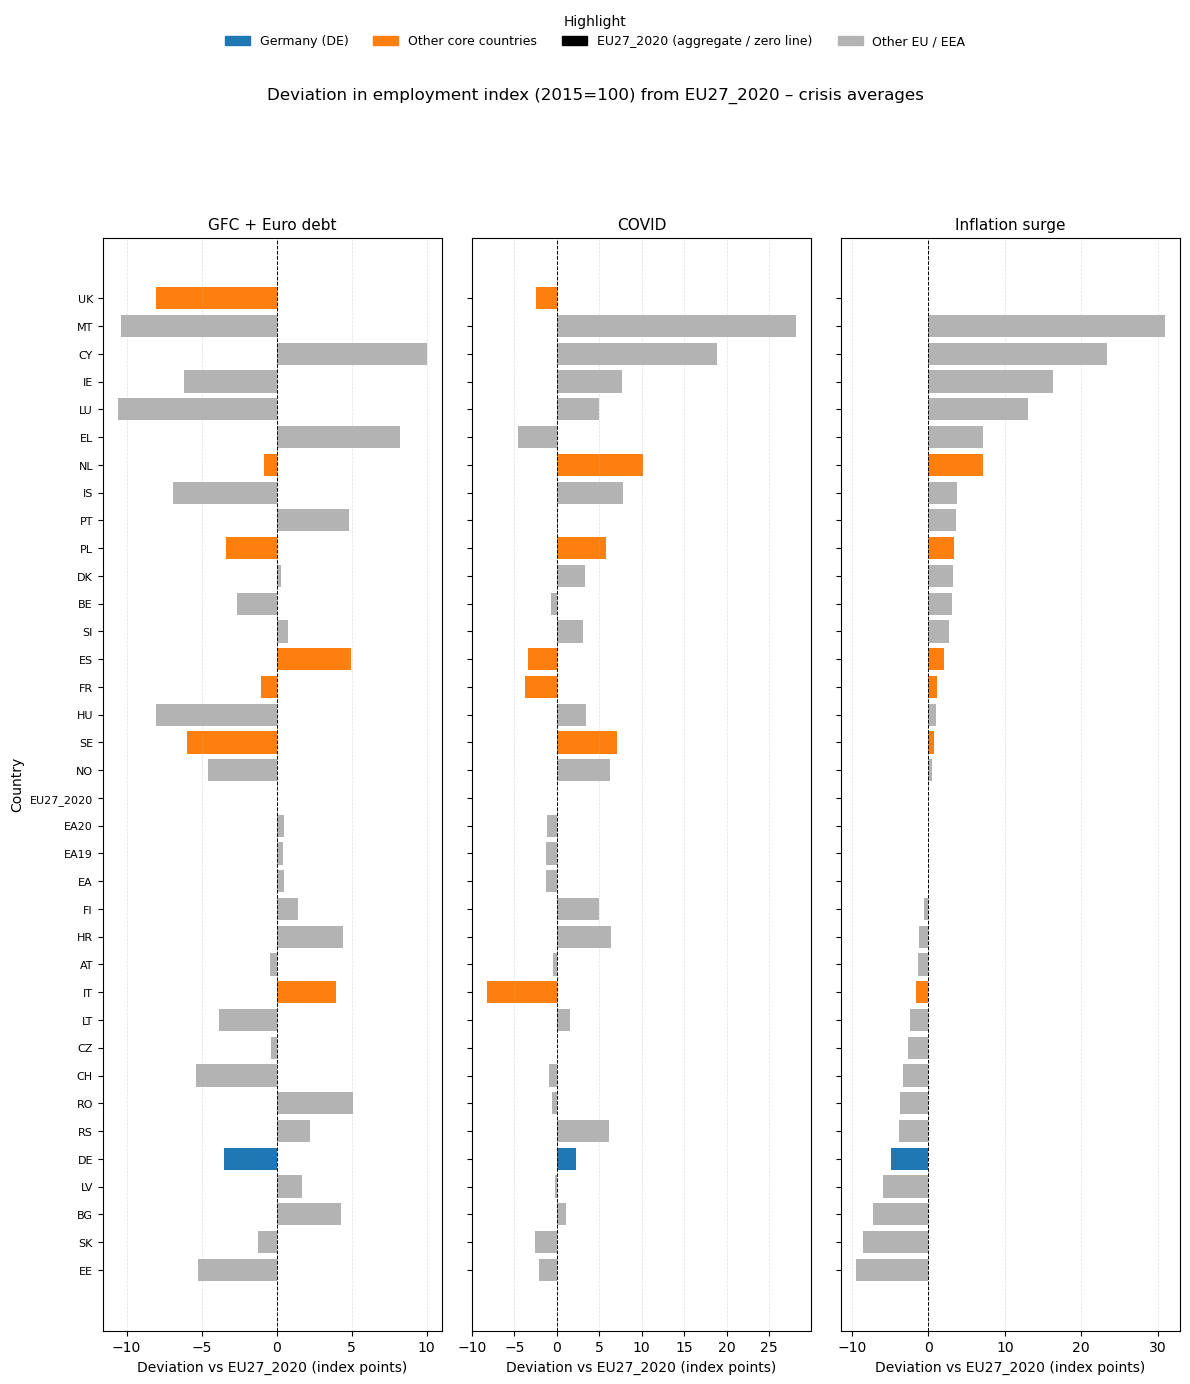

In [27]:
# Employment deviations vs EU27_2020 during each crisis
plot_crisis_bars_shared_y(
    empl_crisis,
    title="Deviation in employment index (2015=100) from EU27_2020 – crisis averages",
    xlabel="Deviation vs EU27_2020 (index points)",
    filename="macro_employment_crisis_bars_shared_y.png",
    sort_by="Inflation surge",    # same order for both figures if you want
)


**3.3.B Deviations in employment index (2015=100) from EU27_2020 – crisis averages**

How to read the figure (quick guide)

- Again, **three panels**:
  - **Left:** GFC + Euro-area debt crisis  
  - **Middle:** COVID shock  
  - **Right:** 2021–23 inflation-surge period  
- The **x-axis** now shows:  
  > average employment index of the country in the crisis  
  > **minus** the average employment index of **EU27_2020**

  - Bars **to the right of zero** → employment **higher** than EU27_2020.  
  - Bars **to the left** → employment **weaker** than the EU average.
- **Colours**:
  - **Blue** – Germany  
  - **Orange** – other core countries (FR, IT, ES, NL, UK, PL, SE)  
  - **Grey** – other EU / EEA economies  
  - **Black dashed vertical line** – EU27_2020 benchmark (0 deviation)
- Countries are **sorted within each panel** by their crisis-specific deviation, highlighting the strongest over- and under-performers.

So this chart answers:  
> *Which labour markets held up better or worse than the EU average in each crisis episode?*


**Economic interpretation**

- **GFC + Euro-debt crisis (left panel)**  
  - The distribution is **skewed to the left**: several countries are well below zero → they suffered **much larger employment losses** than the EU average. These are predominantly **Southern / crisis economies**, consistent with deep recessions, banking problems and austerity.  
  - Germany is clearly **to the right of zero**, confirming the standard story:  
    - intense use of **short-time work schemes (Kurzarbeit)**,  
    - quick industrial rebound after 2009,  
    - and earlier **Hartz labour-market reforms** made German employment unusually resilient.  
  - Some CEE countries also outperform, reflecting **ongoing catch-up and strong labour demand** even through the crisis.  
  - Overall, the GFC/debt episode is both a **level shock** and a **reallocation shock**: employment pain is concentrated in the periphery; Germany and parts of CEE gain relative weight.

- **COVID shock (middle panel)**  
  - A few small economies (e.g. MT, CY) show very **large positive deviations**, where employment ends the window far above EU27_2020 → a mix of small-country volatility, **aggressive job-retention policies** and rapid reopenings.  
  - Germany again outperforms but not as spectacularly as in the GFC; many other countries sit close to zero.  
  - This suggests that **widespread job-retention schemes across Europe compressed cross-country gaps**: COVID was an enormous shock to hours worked and output, but governments deliberately **froze the employment margin**.

- **Inflation-surge period (right panel)**  
  - Deviations become **large and positive** in several CEE and Northern economies: their employment indexes are **well above** EU27_2020 → evidence of **very strong post-COVID labour demand** and, in some cases, **inward migration/refugee inflows**.  
  - Germany is modestly positive but **no longer the clear out-performer**; the relative growth frontier shifts **east and north**.  
  - Some Southern and structurally weaker economies remain near zero or only slightly positive, indicating that the inflation surge did **not** deliver a big employment boom everywhere.

- **Combining inflation and employment deviations**

  - In the **GFC/debt crisis**, Germany shows **below-average inflation and above-average employment** → a classic “core surplus” profile.  
  - In the **inflation surge**, several CEE countries combine **very high inflation with very strong employment** → signs of **overheating and structural catch-up** concentrated in the East.  
  - Economies with **weak employment but no correspondingly low inflation** look vulnerable from a macro-stability point of view (stagflation risk), while those with **strong employment and moderate inflation** emerge as relative “winners” of the post-COVID adjustment.  

  For the later empirical work, this motivates:
  - treating employment as a **crisis-sensitive outcome with strong cross-country heterogeneity**,  
  - and exploring the **joint distribution of inflation and employment deviations** to identify overheating vs. slack country clusters.


In [28]:
# 3.3.3 Cross-sectional dispersion in inflation and employment

def build_cross_sectional_stats(df, value_col, geo_list, agg_geo=AGG_GEO):
    """
    Compute cross-country mean, 10th and 90th percentiles, and EU aggregate
    for each quarter, for a given value column.
    """
    # Keep only the requested geos; drop aggregate from the dispersion
    df_cs = df[df["geo"].isin(geo_list) & (df["geo"] != agg_geo)].copy()

    # Core cross-sectional stats per quarter
    stats = (
        df_cs
        .groupby("timeQuarter")[value_col]
        .agg(
            mean_cs=lambda x: x.mean(skipna=True),
            p10=lambda x: x.quantile(0.10),
            p90=lambda x: x.quantile(0.90),
        )
    )

    # EU27_2020 aggregate series to overlay
    eu_series = (
        df[df["geo"] == agg_geo]
        .set_index("timeQuarter")[value_col]
        .rename("eu")
    )

    stats = stats.join(eu_series)

    # Sort and attach datetime for plotting
    stats = stats.sort_index()
    if isinstance(stats.index, pd.PeriodIndex):
        stats["time_dt"] = stats.index.to_timestamp(how="end")
    else:
        stats["time_dt"] = pd.to_datetime(stats.index)

    return stats


# Build stats for inflation and employment
cs_infl = build_cross_sectional_stats(
    macro_all,
    value_col="hicpInflation",
    geo_list=GEO_LIST_36,
    agg_geo=AGG_GEO,
)

cs_emp = build_cross_sectional_stats(
    macro_all,
    value_col="employmentIndex",
    geo_list=GEO_LIST_36,
    agg_geo=AGG_GEO,
)


In [29]:
def plot_dispersion_band(cs_df, ylabel, title, filename, crisis_windows=CRISIS_WINDOWS_MAIN):
    """
    Plot 10–90 percentile band, cross-country mean and EU aggregate
    over time, with crisis windows shaded.
    """
    # Defensive copy
    df = cs_df.copy()

    # Time axis: use column if present; otherwise derive from index
    if "time_dt" in df.columns:
        t = df["time_dt"]
    else:
        if isinstance(df.index, pd.PeriodIndex):
            t = df.index.to_timestamp(how="end")
        else:
            t = pd.to_datetime(df.index)
        df["time_dt"] = t

    fig, ax = plt.subplots(figsize=(10, 4.5))

    # 10th–90th percentile band
    ax.fill_between(
        t,
        df["p10"],
        df["p90"],
        color="C0",
        alpha=0.25,
        label="10th–90th percentile across countries",
    )

    # Cross-country mean
    ax.plot(
        t,
        df["mean_cs"],
        linestyle="--",
        linewidth=1.2,
        color="C0",
        label="Cross-country mean",
    )

    # EU aggregate
    ax.plot(
        t,
        df["eu"],
        linewidth=2.0,
        color="red",
        label="EU27_2020 (aggregate)",
    )

    # Crisis shading (after main lines so limits are correct)
    ymin, ymax = ax.get_ylim()
    for label, (start_q, end_q) in crisis_windows.items():
        start_ts = pd.Period(start_q, freq="Q-DEC").to_timestamp(how="start")
        end_ts   = pd.Period(end_q,   freq="Q-DEC").to_timestamp(how="end")

        ax.axvspan(start_ts, end_ts, color="lightgrey", alpha=0.18, linewidth=0)

        x_mid = start_ts + (end_ts - start_ts) / 2
        ax.text(
            x_mid,
            ymax,
            label,
            rotation=90,
            ha="center",
            va="top",
            fontsize=7,
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Quarter")

    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
    ax.legend(loc="upper left", fontsize=8)

    fig.tight_layout()

    fig_path = FIGURES_DIR / filename
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved dispersion figure to:", fig_path)

    plt.show()


Saved dispersion figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/macro_inflation_dispersion_band.png


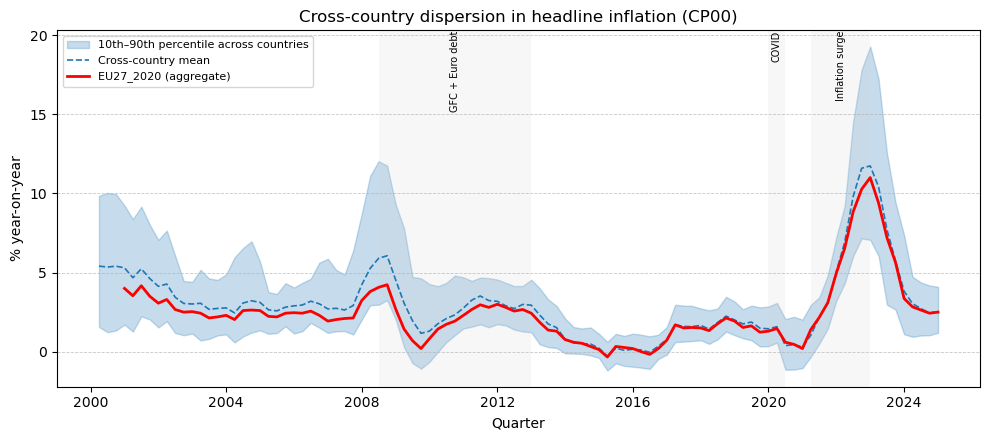

In [30]:
# 3.3.3a Inflation dispersion
plot_dispersion_band(
    cs_infl,
    ylabel="% year-on-year",
    title="Cross-country dispersion in headline inflation (CP00)",
    filename="macro_inflation_dispersion_band.png",
)

**3.3.3 Cross-country dispersion in headline inflation (CP00)**

**What the 10–90% band means**

- For each quarter, we take all available country values of headline inflation (CP00).  
- We compute:
  - **p10 (10th percentile)** – 10% of country observations lie *below* this value.  
  - **p90 (90th percentile)** – 10% lie *above* this value.  
- The blue shaded area is the **[p10, p90] band**: the middle 80% of national inflation outcomes.  
  - It is *not* a confidence interval; it is a cross-sectional dispersion measure.  
- The **blue dashed line** is the **simple cross-country mean**.  
- The **orange line** is the **EU27_2020 aggregate**, i.e. the population-weighted Eurostat series.  
- Grey vertical bands mark the three crisis windows (GFC + Euro debt, COVID, inflation surge).

**Economic interpretation**

- **2000–2007 (pre-GFC):**  
  - Inflation is clustered between roughly 2–5%, and the band is fairly narrow.  
  - The EU aggregate closely tracks the mean → no extreme outliers dominating the area-wide number.

- **2008–2013 (GFC + Euro-area debt):**  
  - Average inflation spikes in 2008–2009, but the **band widens sharply**: some economies flirt with deflation while others stay well above 5%.  
  - Afterwards, both the level and dispersion gradually fall → slow re-anchoring of inflation.

- **2014–2019 (low-inflation regime):**  
  - Inflation is low everywhere and the **10–90% band is unusually tight**.  
  - The EU aggregate sits almost exactly in the middle of the distribution → strong nominal convergence.

- **2021–2023 (inflation surge):**  
  - Both mean and EU aggregate jump to clearly higher levels.  
  - The band becomes **by far the widest in the sample**, showing very heterogeneous pass-through of the energy and supply shocks across member states.

- **By 2024:**  
  - Inflation and dispersion both decline, but dispersion remains wider than in the pre-2019 regime → the euro area has not fully reconverged to the old low-and-similar pattern.


Saved dispersion figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/macro_employment_dispersion_band.png


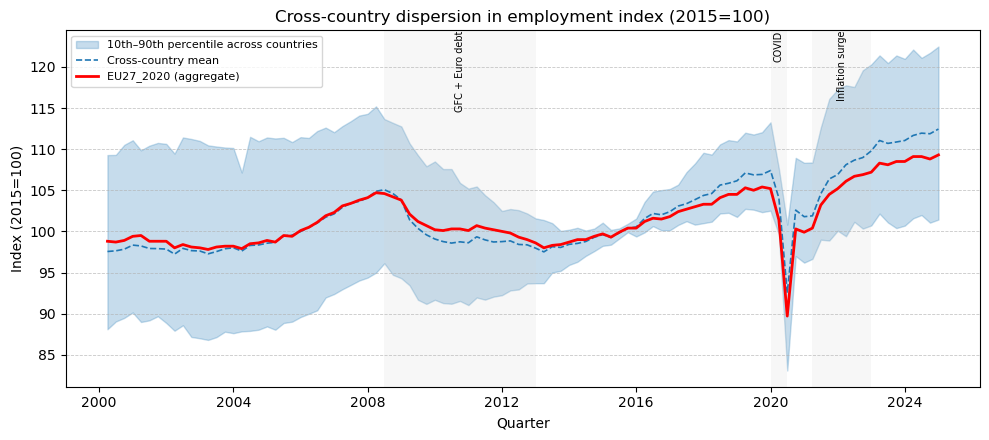

In [31]:
# 3.3.3b Employment dispersion
plot_dispersion_band(
    cs_emp,
    ylabel="Index (2015=100)",
    title="Cross-country dispersion in employment index (2015=100)",
    filename="macro_employment_dispersion_band.png",
)


**3.3.3 Cross-country dispersion in employment (index, 2015 = 100)**

**What the 10–90% band means**

- For each quarter, we use the **employment index (2015 = 100)** for all countries.  
- We compute:
  - **p10** = 10th percentile of national employment indices,  
  - **p90** = 90th percentile.  
- The blue shaded area shows the **middle 80% of countries** in terms of employment levels relative to 2015.  
- The **blue dashed line** is the **unweighted cross-country mean**.  
- The **orange line** is again the **EU27_2020 aggregate**.  
- Crisis periods are shaded as before.

**Economic interpretation**

- **Early 2000s:**  
  - The band is relatively wide: some labour markets are still weak (indices well below 100), others near or above it.  
  - The EU aggregate is slightly above the mean, reflecting larger, better-performing economies.

- **2005–2008 (boom):**  
  - Employment rises broadly and the band narrows a bit → expansion is widespread, not concentrated in a few countries.

- **2008–2013 (GFC + Euro-area debt):**  
  - The mean and EU aggregate flatten or dip, while the **10–90% band widens**.  
  - Some economies suffer deep, persistent employment losses; others hold up much better → highly asymmetric adjustment.

- **2014–2019 (recovery and convergence):**  
  - Both mean and EU aggregate trend steadily upwards; more countries move above 2015=100.  
  - Dispersion gradually falls → weaker labour markets catch up, pointing to real-side convergence in the run-up to COVID.

- **2020–2024 (COVID and aftermath):**  
  - COVID generates a **sharp but short-lived drop** in mean and aggregate employment, with a temporary spike in dispersion.  
  - The subsequent recovery overshoots pre-COVID levels and dispersion increases again: almost all countries gain jobs, but **some far more than others**.  
  - The euro area ends the period with **higher average employment but more heterogeneity**, which matters for how evenly monetary tightening and inflation shocks are transmitted across member states.


### Q4 — Income distribution & inequality dynamics (30 quantiles → 5 groups)

### Research question
How does the **distribution of income** evolve across European countries over time, and how do major crisis periods (GFC/Euro debt, COVID, inflation surge) relate to shifts in **inequality**?

### What we use
- **Income shares** by country and quantile (30 quantiles per country-year, repeated across quarters in the master panel).
- We collapse the 30 quantiles into **5 equal-population groups**:
  - **Bottom 20%** (Q1–Q6)
  - **Lower-middle 20%** (Q7–Q12)
  - **Middle 20%** (Q13–Q18)
  - **Upper-middle 20%** (Q19–Q24)
  - **Top 20%** (Q25–Q30)
- Key summaries we’ll derive:
  - Group shares over time (levels, in percentage points)
  - Inequality indicators such as **Top20 − Bottom20**, **Top20 / Bottom20**, and **Top10 share** (Q28–Q30)

### Why we treat income as annual
The income distribution data are fundamentally **annual**; in the quarterly master panel, the same annual income shares are repeated across quarters.  
For clarity (and to avoid fake “quarterly wiggles”), we analyse income at the **yearly** frequency and only later replicate features back to quarters for ML merging.

### Structure of this section
1. **Prepare yearly income distribution data** (deduplicate quarters, build 5 groups).
2. **EU baseline**: how group shares and inequality evolve over time.
3. **Comparators**: Germany vs EU; core-EU vs EU (UK shown separately, not treated as “EU core”).
4. **All-geo context**: dispersion bands across countries (p10–p90) with EU/DE overlays.
5. **Feature export**: ML-ready yearly (and replicated quarterly) income features.


In [32]:
# --- Q4.1 (FIX) Annual quintile shares from DECILES ONLY (D1..D10) + index without groupby.apply ---

BASE_YEAR = 2010
EU_GEO = "EU27_2020"
DE_GEO = "DE"

# 0) Load panel
if "macro" in globals():
    df = macro.copy()
else:
    df = pd.read_parquet(DATA_PROCESSED / "master_quarterly_panel.parquet")

income = df.loc[
    (df["indic_il"] == "SHARE") & (df["currency"] == "EUR"),
    ["geo", "timeQuarter", "quantile", "incomeValue"]
].copy()

income["year"] = income["timeQuarter"].dt.year
income["quantile"] = income["quantile"].astype(str)

# 1) KEEP ONLY DECILES (prevents P95..P100 double-counting)
income_dec = income.loc[income["quantile"].str.fullmatch(r"D(10|[1-9])")].copy()
income_dec["decile"] = income_dec["quantile"].str.replace("D", "", regex=False).astype(int)

# 2) Deduplicate quarterly repeats -> annual mean per decile
annual_dec = (
    income_dec
    .groupby(["geo", "year", "decile"], as_index=False)["incomeValue"]
    .mean()
    .rename(columns={"incomeValue": "dec_share"})
)

# 3) Map 10 deciles -> 5 quintile groups (2 deciles each)
def dec_to_group5(d):
    if d <= 2:  return "Bottom 20%"
    if d <= 4:  return "Lower-middle 20%"
    if d <= 6:  return "Middle 20%"
    if d <= 8:  return "Upper-middle 20%"
    return "Top 20%"

annual_dec["group5"] = annual_dec["decile"].map(dec_to_group5)

annual_g = (
    annual_dec
    .groupby(["geo", "year", "group5"], as_index=False)["dec_share"]
    .sum()
    .rename(columns={"dec_share": "share_pct"})
)

# Top 10% = D10 (decile 10)
top10 = (
    annual_dec.loc[annual_dec["decile"] == 10, ["geo", "year", "dec_share"]]
    .rename(columns={"dec_share": "Top 10%"})
)

# 4) Add index-to-base-year WITHOUT groupby.apply (no warning)
base = (
    annual_g.loc[annual_g["year"] == BASE_YEAR, ["geo", "group5", "share_pct"]]
    .rename(columns={"share_pct": "base_share"})
)

annual_g = annual_g.merge(base, on=["geo", "group5"], how="left")
annual_g["share_index"] = (annual_g["share_pct"] / annual_g["base_share"]) * 100

# 5) Sanity checks
chk = annual_g.groupby(["geo", "year"], as_index=False)["share_pct"].sum()
print("Sum of 5 groups (median/min/max):",
      float(chk["share_pct"].median()), float(chk["share_pct"].min()), float(chk["share_pct"].max()))

print("EU27_2020 years min/max:",
      int(annual_g.loc[annual_g["geo"].eq(EU_GEO), "year"].min()),
      int(annual_g.loc[annual_g["geo"].eq(EU_GEO), "year"].max()))

annual_g.head(10)


Sum of 5 groups (median/min/max): 100.0 0.0 102.0
EU27_2020 years min/max: 2000 2024


,geo,year,group5,share_pct,base_share,share_index
0,AT,2000,Bottom 20%,10.0,8.6,116.27907
1,AT,2000,Lower-middle 20%,15.0,14.0,107.142857
2,AT,2000,Middle 20%,19.0,17.9,106.145251
3,AT,2000,Top 20%,34.0,37.1,91.644205
4,AT,2000,Upper-middle 20%,23.0,22.4,102.678571
5,AT,2001,Bottom 20%,10.0,8.6,116.27907
6,AT,2001,Lower-middle 20%,15.0,14.0,107.142857
7,AT,2001,Middle 20%,19.0,17.9,106.145251
8,AT,2001,Top 20%,34.0,37.1,91.644205
9,AT,2001,Upper-middle 20%,23.0,22.4,102.678571


In [33]:
# --- Q4.2 (cleanup) Keep only valid geo-years: all 10 deciles present + sums ~100 ---

# Rebuild a strict coverage table from annual_dec (deciles) used above
coverage = (
    annual_dec.groupby(["geo", "year"], as_index=False)
             .agg(n_deciles=("decile", "nunique"),
                  sum_dec=("dec_share", "sum"))
)

# Identify scale (100 vs 1000) and compute percent sum
median_sum = float(coverage["sum_dec"].median())
scale = 1000 if median_sum > 200 else 100
coverage["sum_pct"] = coverage["sum_dec"] * (100 / scale)

coverage["ok"] = (coverage["n_deciles"] == 10) & coverage["sum_pct"].between(98, 102)

print("OK share of rows:", coverage["ok"].mean())
print("Example bad rows:")
display(coverage.loc[~coverage["ok"]].head(10))

# Filter annual_g to only OK geo-years
annual_g_ok = (
    annual_g.merge(coverage[["geo", "year", "ok"]], on=["geo", "year"], how="left")
            .query("ok == True")
            .drop(columns=["ok"])
)

# Check EU27 availability after strict filtering
EU_GEO = "EU27_2020"
eu_years = annual_g_ok.loc[annual_g_ok["geo"].eq(EU_GEO), "year"].unique()
print("EU27_2020 valid years min/max:",
      int(np.min(eu_years)) if len(eu_years) else None,
      int(np.max(eu_years)) if len(eu_years) else None,
      "| count:", len(eu_years))

annual_g_ok.head(10)


OK share of rows: 0.7977777777777778
Example bad rows:


,geo,year,n_deciles,sum_dec,sum_pct,ok
2,AT,2002,10,0.0,0.0,False
27,BE,2002,10,0.0,0.0,False
50,BG,2000,10,0.0,0.0,False
51,BG,2001,10,0.0,0.0,False
52,BG,2002,10,0.0,0.0,False
53,BG,2003,10,0.0,0.0,False
54,BG,2004,10,0.0,0.0,False
55,BG,2005,10,0.0,0.0,False
75,CH,2000,10,0.0,0.0,False
76,CH,2001,10,0.0,0.0,False


EU27_2020 valid years min/max: 2010 2024 | count: 15


,geo,year,group5,share_pct,base_share,share_index
0,AT,2000,Bottom 20%,10.0,8.6,116.27907
1,AT,2000,Lower-middle 20%,15.0,14.0,107.142857
2,AT,2000,Middle 20%,19.0,17.9,106.145251
3,AT,2000,Top 20%,34.0,37.1,91.644205
4,AT,2000,Upper-middle 20%,23.0,22.4,102.678571
5,AT,2001,Bottom 20%,10.0,8.6,116.27907
6,AT,2001,Lower-middle 20%,15.0,14.0,107.142857
7,AT,2001,Middle 20%,19.0,17.9,106.145251
8,AT,2001,Top 20%,34.0,37.1,91.644205
9,AT,2001,Upper-middle 20%,23.0,22.4,102.678571


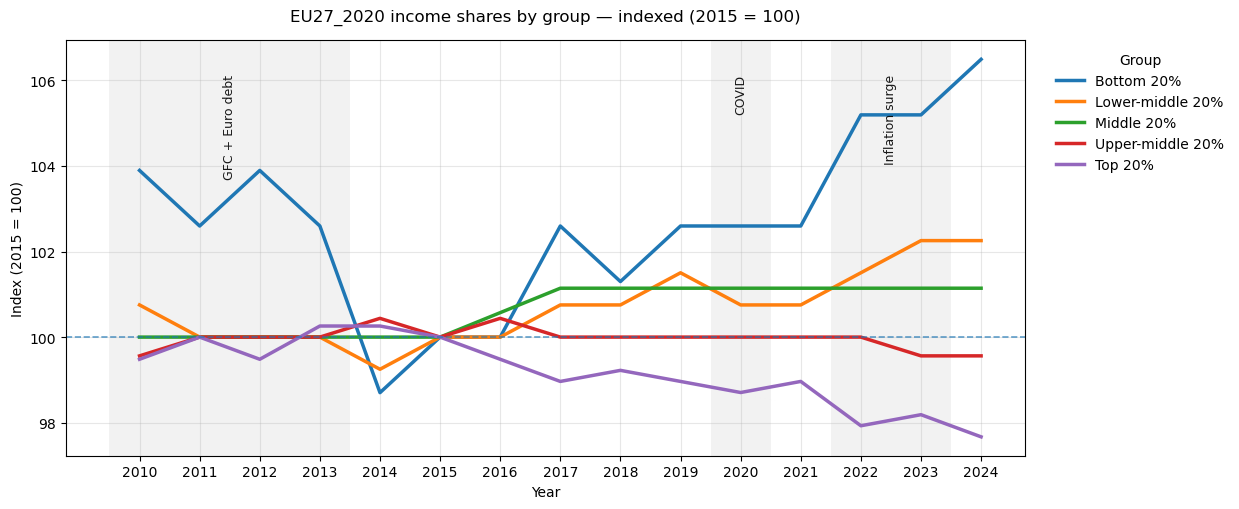

In [34]:
# --- Q4.4b EU27_2020 all groups (2015=100) + crisis windows (labels inside bands) ---

EU_GEO = "EU27_2020"
BASE_YEAR = 2015
groups = ["Bottom 20%", "Lower-middle 20%", "Middle 20%", "Upper-middle 20%", "Top 20%"]

eu_long = (
    annual_g_ok.loc[(annual_g_ok["geo"] == EU_GEO) & (annual_g_ok["group5"].isin(groups)),
                    ["year", "group5", "share_pct"]]
    .sort_values(["group5", "year"])
)

base = (
    eu_long.loc[eu_long["year"] == BASE_YEAR, ["group5", "share_pct"]]
          .rename(columns={"share_pct": "base_share"})
)
eu_long = eu_long.merge(base, on="group5", how="left")
eu_long["index_2015"] = (eu_long["share_pct"] / eu_long["base_share"]) * 100
eu_w = eu_long.pivot(index="year", columns="group5", values="index_2015").sort_index()

crises = [
    ("GFC + Euro debt", 2010, 2013),
    ("COVID", 2020,2020),
    ("Inflation surge", 2022, 2023),
]

fig, ax = plt.subplots(figsize=(12.5, 5.2))

# Plot lines first (so we can compute y-limits before placing labels)
for g in groups:
    ax.plot(eu_w.index, eu_w[g], linewidth=2.5, label=g)

ax.axhline(100, linestyle="--", linewidth=1.2, alpha=0.7)

# Set title with a bit of padding (keeps top clean)
ax.set_title("EU27_2020 income shares by group — indexed (2015 = 100)", pad=14)
ax.set_xlabel("Year")
ax.set_ylabel("Index (2015 = 100)")
ax.grid(True, alpha=0.3)

# Crisis shading + vertical labels INSIDE shaded area (like your reference chart)
ymin, ymax = ax.get_ylim()
y_text = ymin + 0.92 * (ymax - ymin)  # near top but inside plot

for label, y0, y1 in crises:
    ax.axvspan(y0 - 0.5, y1 + 0.5, alpha=0.10, color="grey", linewidth=0)
    ax.text((y0 + y1) / 2, y_text, label,
            ha="center", va="top", rotation=90, fontsize=9, alpha=0.9)

# Clean x ticks (annual)
ax.set_xticks(eu_w.index)

# Legend outside, no frame
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Group")

plt.tight_layout()
plt.show()


**EU27_2020 income shares by group — indexed (2015 = 100), with crisis windows**

This chart summarizes how the EU27 income distribution (quintile shares constructed from deciles) evolves over time, using **2015 as the baseline**. Each line tracks the *income share* of a population group relative to its own 2015 level (2015 = 100). Values above 100 indicate that group’s share of total income is higher than in 2015; values below 100 indicate it is lower.

**Overall pattern (distributional drift):**
- The **Top 20%** trends downward after 2015 and ends clearly below 100 by 2024, implying a gradual decline in the top quintile’s share of total income relative to 2015.
- The **Bottom 20%** rises meaningfully above 100 by the end of the sample, indicating an increase in the bottom quintile’s share relative to 2015. The strongest gains appear after 2021.
- The **Lower-middle 20%** also drifts upward, but more modestly than the bottom quintile.
- The **Middle 20%** and **Upper-middle 20%** remain comparatively stable around the baseline, showing that most of the long-run movement is concentrated in the tails (top vs bottom).

**Crisis-window context (shaded bands):**
- During **GFC + Euro debt**, the lines show modest movement, but no abrupt structural break at the EU27 aggregate level—consistent with income shares being slow-moving and shaped by institutional and policy adjustments over multiple years.
- The **COVID** window shows relatively limited immediate reallocation in this annual distribution measure (again: shares tend to move gradually, and EU aggregation smooths country-level shocks).
- The **Inflation surge** period aligns with the clearest divergence: bottom and lower-middle groups rise while the top group declines, suggesting distributional shifts that are strongest in the post-2021 period.

**How to read magnitudes:**
Because this is an index, a move from 100 to 106 for the Bottom 20% means the bottom group’s income share is ~6% higher than its 2015 share (not that incomes are 6% higher in euros). This is a compositional change in how total income is split across the population.

**Takeaway:** The EU27 income distribution shows a mild but persistent rebalancing away from the top quintile toward the bottom (and slightly toward the lower-middle) since 2015, with the most visible divergence occurring after 2021.


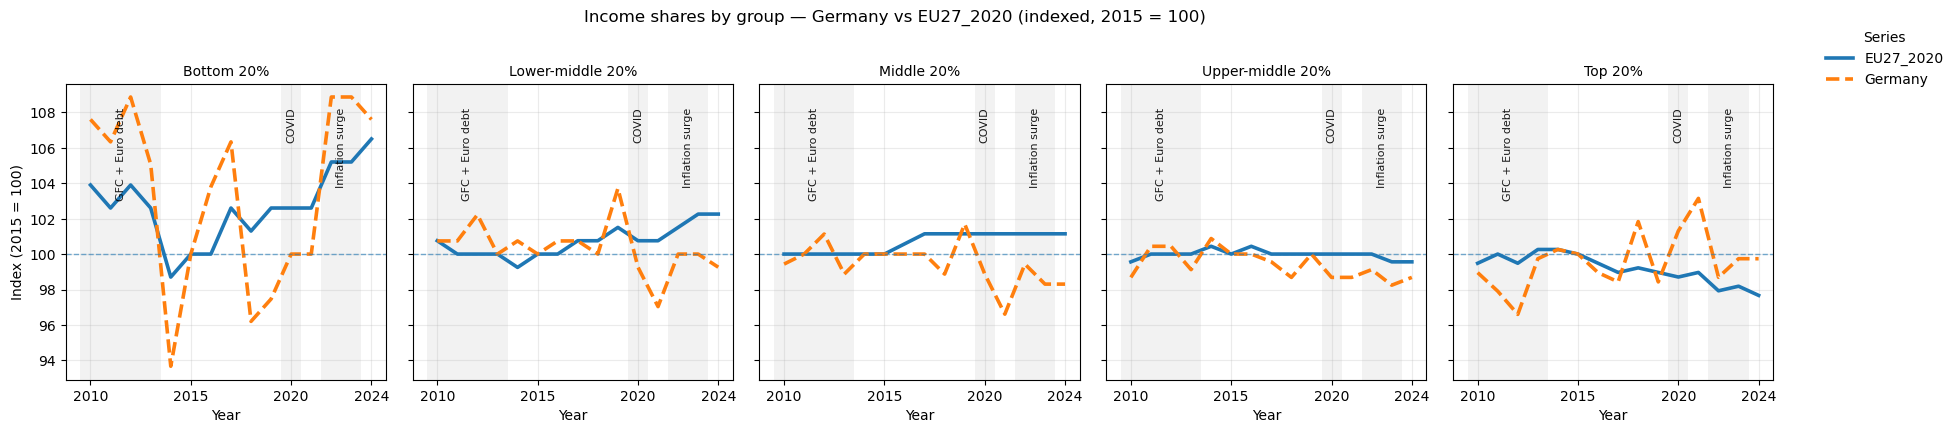

In [35]:
# --- Q4.8 Germany vs EU27_2020 — small multiples (one panel per group), indexed 2015=100 ---

BASE_YEAR = 2015
EU_GEO = "EU27_2020"
DE_GEO = "DE"
groups = ["Bottom 20%", "Lower-middle 20%", "Middle 20%", "Upper-middle 20%", "Top 20%"]

crises = [
    ("GFC + Euro debt", 2010, 2013),
    ("COVID", 2020, 2020),
    ("Inflation surge", 2022, 2023),
]

# Build long series (reuse your annual_g_ok)
cmp_long = (
    annual_g_ok.loc[(annual_g_ok["geo"].isin([EU_GEO, DE_GEO])) & (annual_g_ok["group5"].isin(groups)),
                    ["geo", "year", "group5", "share_pct"]]
    .dropna()
    .sort_values(["geo", "group5", "year"])
)

# Index each (geo, group) to BASE_YEAR
base = (
    cmp_long.loc[cmp_long["year"] == BASE_YEAR, ["geo", "group5", "share_pct"]]
            .rename(columns={"share_pct": "base_share"})
)
cmp_long = cmp_long.merge(base, on=["geo", "group5"], how="left")
cmp_long["index_2015"] = (cmp_long["share_pct"] / cmp_long["base_share"]) * 100

# Pivot per geo for plotting
eu = (cmp_long.loc[cmp_long["geo"] == EU_GEO]
              .pivot(index="year", columns="group5", values="index_2015")
              .sort_index())
de = (cmp_long.loc[cmp_long["geo"] == DE_GEO]
              .pivot(index="year", columns="group5", values="index_2015")
              .sort_index())

common_years = sorted(set(eu.index).intersection(set(de.index)))
eu = eu.loc[common_years]
de = de.loc[common_years]

# --- Plot small multiples ---
fig, axes = plt.subplots(1, 5, figsize=(18, 4.2), sharey=True)

for ax, g in zip(axes, groups):
    # crisis bands + labels (place labels near top inside band)
    # compute y-text after lines are drawn -> use a safe placement after setting limits
    for label, y0, y1 in crises:
        ax.axvspan(y0 - 0.5, y1 + 0.5, alpha=0.10, color="grey", linewidth=0)

    # EU solid vs DE dashed (same color within panel)
    ax.plot(common_years, eu[g], linewidth=2.6, label="EU27_2020")
    ax.plot(common_years, de[g], linewidth=2.6, linestyle="--", label="Germany")

    ax.axhline(100, linestyle="--", linewidth=1.0, alpha=0.6)
    ax.set_title(g, fontsize=10)
    ax.grid(True, alpha=0.25)
    ax.set_xlabel("Year")
    ax.set_xticks([2010, 2015, 2020, 2024])

    # crisis labels (vertical, centered, placed high)
    ymin, ymax = ax.get_ylim()
    y_text = ymin + 0.92 * (ymax - ymin)
    for label, y0, y1 in crises:
        ax.text((y0 + y1) / 2, y_text, label, ha="center", va="top",
                rotation=90, fontsize=8, alpha=0.9)

axes[0].set_ylabel("Index (2015 = 100)")

# One shared legend, outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.01, 1.0),
           frameon=False, title="Series")

fig.suptitle("Income shares by group — Germany vs EU27_2020 (indexed, 2015 = 100)", y=1.02)
plt.tight_layout()
plt.show()


In [36]:
# --- Save figure: DE vs EU27 small-multiples income groups ---

out_path = FIGURES_DIR / "income_groups_DE_vs_EU27_small_multiples_indexed_2015.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print("Saved figure to:", out_path)


Saved figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/income_groups_DE_vs_EU27_small_multiples_indexed_2015.png


**Germany vs EU27_2020: income-share distribution by group (indexed, 2015 = 100)**

This figure compares how the **income shares** of five population groups (Bottom 20% → Top 20%) evolved in **Germany** versus the **EU27_2020 aggregate**. Values are **indexed to 2015 = 100**, so each line shows **relative change from the 2015 baseline** for that group (not the absolute share level).

**How to read it**
- **Solid line (EU27_2020)** vs **dashed line (Germany)** within each panel.
- The horizontal line at **100** is the 2015 baseline:  
  - Above 100 → the group’s share is *higher than in 2015*  
  - Below 100 → the share is *lower than in 2015*
- Shaded bands mark major macro episodes (GFC/Euro debt, COVID, inflation surge) to help visually align distribution shifts with stress periods.

**What stands out**
- **Bottom 20%:** EU27 shows a clearer upward drift after the mid-2010s and especially post-2021, while Germany exhibits larger swings (a deeper mid-2010s dip and a sharp rebound later). This suggests **greater volatility** in Germany’s lower-tail income share relative to the EU aggregate.
- **Lower-middle 20%:** EU27 trends mildly upward after 2015; Germany is flatter-to-down in later years. The gap indicates that the **lower-middle share improved more at EU level** than in Germany.
- **Middle 20%:** Both series are nearly flat around the baseline, implying that the **middle of the distribution is comparatively stable** in share terms (distributional adjustments appear to happen more in the tails).
- **Upper-middle 20%:** EU27 is broadly stable; Germany edges slightly below baseline in recent years, indicating a **small relative compression** of this group’s share versus 2015.
- **Top 20%:** EU27 trends modestly down post-2015, whereas Germany shows more pronounced cyclical movement (notably around 2019–2022). Overall, the picture is consistent with **mild top-share softening at EU level** and **more fluctuation in Germany**.

**Interpretation note**
These are **shares of total income**, so movements reflect distributional shifts (who gets what slice of the pie), not changes in overall income levels. Absolute income growth would require a level series (e.g., mean/median income), which is not present in this dataset block.


In section **Q4.A** we compare **Core EU vs EU27_2020** and used a **p10–p90 band** to show how wide the Core distribution is for each income group.

In [37]:
# --- Q4.A Core band vs EU27 reference using DECILES ONLY (D1..D10) ---

BASE_YEAR = 2015
EU_GEO = "EU27_2020"

CORE_GEOS = ["DE", "FR", "IT", "ES", "NL", "PL", "SE"]  # UK excluded (Brexit)

# Use already-loaded master panel if available
if "macro" in globals():
    df = macro.copy()
else:
    df = pd.read_parquet(DATA_PROCESSED / "master_quarterly_panel.parquet")

# 1) Pull income shares and KEEP ONLY DECILES (D1..D10)
inc = df.loc[
    (df["indic_il"] == "SHARE") & (df["currency"] == "EUR"),
    ["geo", "timeQuarter", "quantile", "incomeValue"]
].copy()
inc["year"] = inc["timeQuarter"].dt.year

qstr = inc["quantile"].astype(str).str.upper().str.strip()
inc = inc.loc[qstr.str.fullmatch(r"D([1-9]|10)")].copy()

inc["decile"] = qstr.str.extract(r"(\d+)").astype(int)

# Deduplicate quarter repeats -> one value per (geo, year, decile)
inc_a = (
    inc.groupby(["geo", "year", "decile"], as_index=False)["incomeValue"]
       .mean()
)

# 2) Map deciles -> 5 groups (20% each)
def _group5_from_decile(d):
    if 1 <= d <= 2:   return "Bottom 20%"
    if 3 <= d <= 4:   return "Lower-middle 20%"
    if 5 <= d <= 6:   return "Middle 20%"
    if 7 <= d <= 8:   return "Upper-middle 20%"
    if 9 <= d <= 10:  return "Top 20%"
    return pd.NA

inc_a["group5"] = inc_a["decile"].map(_group5_from_decile)

g = (
    inc_a.dropna(subset=["group5"])
         .groupby(["geo", "year", "group5"], as_index=False)["incomeValue"]
         .sum()
         .rename(columns={"incomeValue": "share_raw"})
)

# 3) Quality check: must have all 10 deciles and totals ~100 (or ~1000)
chk = (
    inc_a.groupby(["geo", "year"], as_index=False)
         .agg(n_deciles=("decile", "nunique"))
)
sum_all = g.groupby(["geo", "year"], as_index=False)["share_raw"].sum().rename(columns={"share_raw": "sum_all"})

chk = chk.merge(sum_all, on=["geo", "year"], how="left")

median_sum = float(chk["sum_all"].median())
scale = 1000 if median_sum > 200 else 100
chk["sum_pct"] = chk["sum_all"] * (100 / scale)

chk["ok"] = (chk["n_deciles"] == 10) & chk["sum_pct"].between(98, 102)

print(f"Decile-only check: median sum_all={median_sum:.1f} -> scale~{scale}")
print("EU27 ok years:", chk.loc[(chk["geo"] == EU_GEO) & (chk["ok"]), "year"].min(),
      "→", chk.loc[(chk["geo"] == EU_GEO) & (chk["ok"]), "year"].max())

# Convert to percent
g = g.merge(chk[["geo", "year", "ok"]], on=["geo", "year"], how="left")
g = g.loc[g["ok"]].copy()
g["share_pct"] = g["share_raw"] * (100 / scale)

# 4) Index each (geo, group5) to BASE_YEAR = 100
base = (
    g.loc[g["year"] == BASE_YEAR, ["geo", "group5", "share_pct"]]
     .rename(columns={"share_pct": "base_share"})
)
g = g.merge(base, on=["geo", "group5"], how="left")
g["share_index"] = (g["share_pct"] / g["base_share"]) * 100

# 5) Core band + EU27 + DE series (ready for plotting)
core = g.loc[g["geo"].isin(CORE_GEOS)].copy()

core_band = (
    core.groupby(["year", "group5"], as_index=False)
        .agg(
            core_mean=("share_index", "mean"),
            core_p10 =("share_index", lambda s: s.quantile(0.10)),
            core_p90 =("share_index", lambda s: s.quantile(0.90)),
            n_core   =("share_index", "count"),
        )
)

eu27 = (
    g.loc[g["geo"] == EU_GEO, ["year", "group5", "share_index"]]
     .rename(columns={"share_index": "eu27_index"})
)
de = (
    g.loc[g["geo"] == "DE", ["year", "group5", "share_index"]]
     .rename(columns={"share_index": "de_index"})
)

core_band = (core_band.merge(eu27, on=["year", "group5"], how="left")
                     .merge(de,   on=["year", "group5"], how="left")
                     .sort_values(["group5", "year"]))

display(core_band.head(10))


Decile-only check: median sum_all=100.0 -> scale~100
EU27 ok years: 2010 → 2024


,year,group5,core_mean,core_p10,core_p90,n_core,eu27_index,de_index
0,2000,Bottom 20%,117.368328,102.105263,131.988844,5,<NA>,126.582278
5,2001,Bottom 20%,117.368328,102.105263,131.988844,5,<NA>,126.582278
10,2004,Bottom 20%,111.576945,102.238806,121.145053,4,<NA>,<NA>
15,2005,Bottom 20%,106.338048,89.878748,119.527998,7,<NA>,118.987342
20,2006,Bottom 20%,105.421075,95.824117,114.29307,7,<NA>,111.392405
25,2007,Bottom 20%,106.12131,97.217855,117.903035,7,<NA>,98.734177
30,2008,Bottom 20%,105.282247,98.398401,114.40425,7,<NA>,102.531646
35,2009,Bottom 20%,104.394701,97.847953,111.692386,7,<NA>,107.594937
40,2010,Bottom 20%,104.464837,99.111111,109.440931,7,103.896104,107.594937
45,2011,Bottom 20%,102.088181,97.590643,107.187299,7,102.597403,106.329114


In [38]:
# --- Q4.A.1 Restrict to overlap window (EU27 available) + sanity checks ---

ANALYSIS_START = 2010
ANALYSIS_END   = 2024

core_band_q4 = (
    core_band
    .loc[core_band["year"].between(ANALYSIS_START, ANALYSIS_END)]
    .dropna(subset=["eu27_index"])   # keep only years where EU27 exists
    .copy()
)

# Optional: require at least 5 core countries contributing to the band each year
core_band_q4 = core_band_q4.loc[core_band_q4["n_core"] >= 5].copy()

print("Window years:", core_band_q4["year"].min(), "→", core_band_q4["year"].max())
print("Rows:", core_band_q4.shape)

# Quick check: should have 5 groups each year (if complete)
check = core_band_q4.groupby("year")["group5"].nunique()
print("Groups per year (min/median/max):", check.min(), check.median(), check.max())

display(core_band_q4.head(10))


Window years: 2010 → 2024
Rows: (75, 8)
Groups per year (min/median/max): 5 5.0 5


,year,group5,core_mean,core_p10,core_p90,n_core,eu27_index,de_index
40,2010,Bottom 20%,104.464837,99.111111,109.440931,7,103.896104,107.594937
45,2011,Bottom 20%,102.088181,97.590643,107.187299,7,102.597403,106.329114
50,2012,Bottom 20%,102.96211,99.808786,106.595151,7,103.896104,108.860759
55,2013,Bottom 20%,102.226952,99.364341,105.749839,7,102.597403,105.063291
60,2014,Bottom 20%,99.008309,96.205197,100.597015,7,98.701299,93.670886
65,2015,Bottom 20%,100.0,100.0,100.0,7,100.0,100.0
70,2016,Bottom 20%,99.82087,95.717203,104.312379,7,100.0,103.797468
75,2017,Bottom 20%,100.813451,96.982456,105.56962,7,102.597403,106.329114
80,2018,Bottom 20%,101.420755,95.616256,110.821712,7,101.298701,96.202532
85,2019,Bottom 20%,101.331574,96.244798,109.980691,7,102.597403,97.468354


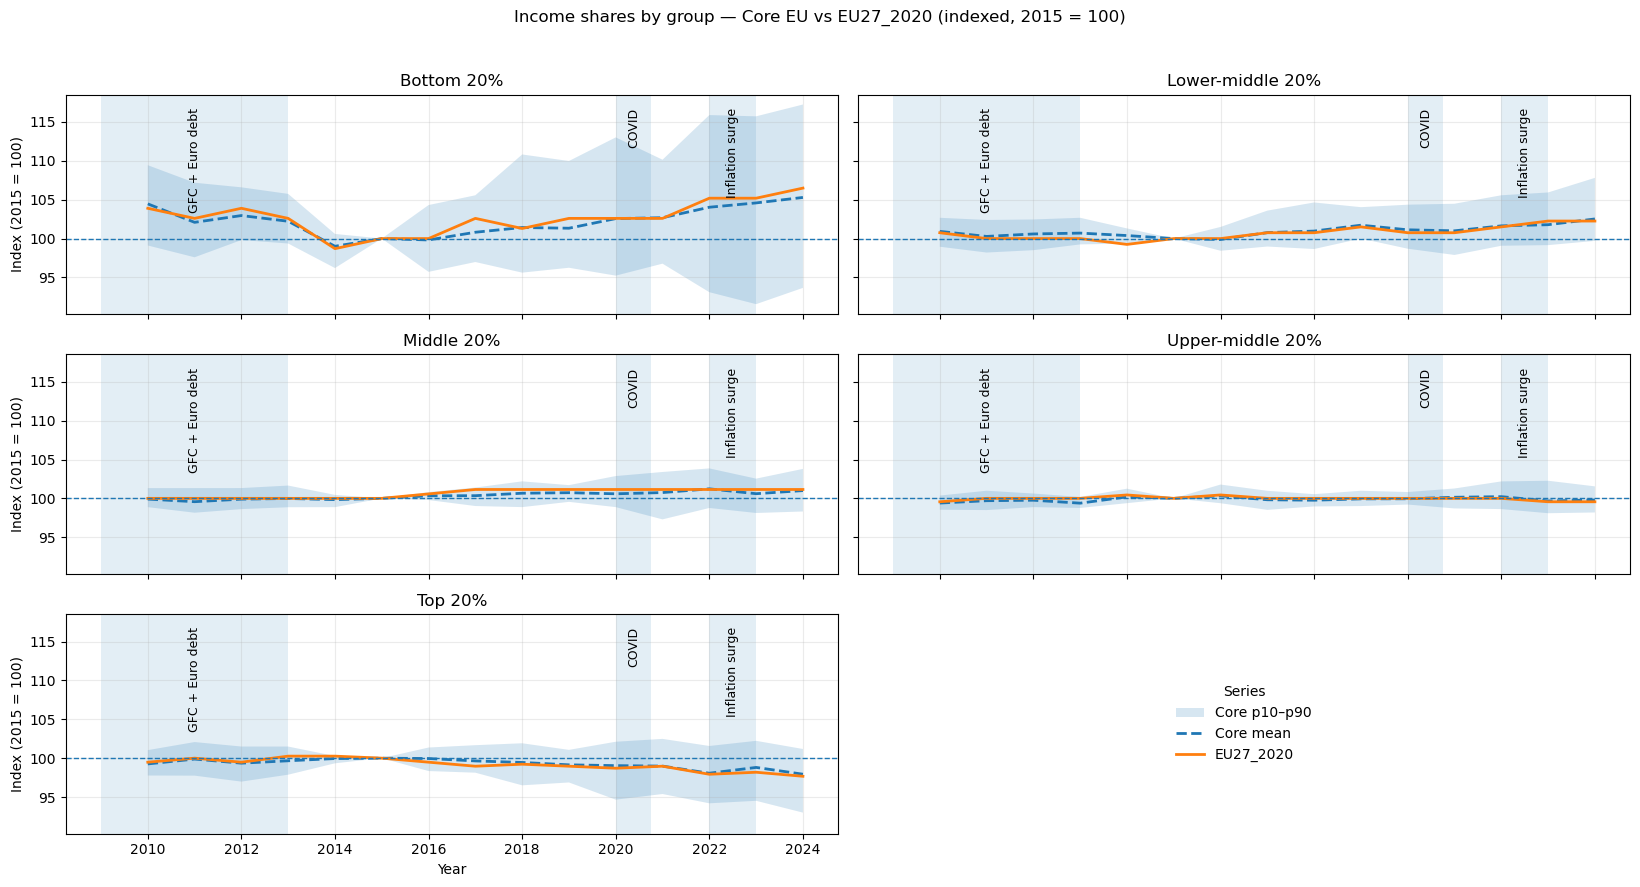

In [39]:
# --- Q4.X Re-plot: 3x2 grid (5 panels + 1 legend panel), wider x-axis, ticks every 2 years ---

plot_df = core_band_q4.copy()
groups_order = ["Bottom 20%", "Lower-middle 20%", "Middle 20%", "Upper-middle 20%", "Top 20%"]

# 3 rows x 2 cols; last cell reserved for legend
fig, axes = plt.subplots(
    3, 2, figsize=(16.5, 9.0),
    sharex=True, sharey=True
)

# Map 5 groups onto first 5 axes; keep last axis for legend
axes_list = [axes[0,0], axes[0,1], axes[1,0], axes[1,1], axes[2,0]]
ax_leg = axes[2,1]
ax_leg.axis("off")

# Crisis windows (edit if your definitions differ)
CRISES = [
    ("GFC + Euro debt", 2009.0, 2013.0),
    ("COVID",           2020.0, 2020.75),
    ("Inflation surge", 2022.0, 2023.0),
]

for ax, g in zip(axes_list, groups_order):
    d = plot_df.loc[plot_df["group5"] == g].sort_values("year")

    # Shaded dispersion band: core p10–p90 (across core countries)
    band = ax.fill_between(d["year"], d["core_p10"], d["core_p90"], alpha=0.18, label="Core p10–p90")

    # Core mean (dashed) + EU27 (solid)
    ln_core, = ax.plot(d["year"], d["core_mean"], linestyle="--", linewidth=2, label="Core mean")
    ln_eu,   = ax.plot(d["year"], d["eu27_index"], linewidth=2, label="EU27_2020")

    # Baseline
    ax.axhline(100, linestyle="--", linewidth=1)

    # Crisis shading + labels inside the shaded bands
    y0, y1 = ax.get_ylim()
    y_text = y1 - 0.06 * (y1 - y0)
    for name, a, b in CRISES:
        ax.axvspan(a, b, alpha=0.12)
        ax.text((a + b) / 2, y_text, name, rotation=90, va="top", ha="center", fontsize=9)

    ax.set_title(g, fontsize=12)
    ax.grid(True, alpha=0.25)

# X ticks every 2 years (2010, 2012, ...)
years = np.arange(2010, 2025, 2)
for ax in axes_list:
    ax.set_xticks(years)
    ax.tick_params(axis="x", labelrotation=0)

# Labels
axes[2,0].set_xlabel("Year")
axes[2,1].set_xlabel("")  # legend cell
axes[0,0].set_ylabel("Index (2015 = 100)")
axes[1,0].set_ylabel("Index (2015 = 100)")
axes[2,0].set_ylabel("Index (2015 = 100)")

fig.suptitle("Income shares by group — Core EU vs EU27_2020 (indexed, 2015 = 100)", y=0.98)

# Put a clean legend in the empty 6th panel
ax_leg.legend(handles=[band, ln_core, ln_eu],
              labels=["Core p10–p90", "Core mean", "EU27_2020"],
              title="Series", loc="center", frameon=False)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [40]:
# --- Q4.X Save figure: Core EU vs EU27 (3x2 grid) ---

fig_path = FIGURES_DIR / "income_coreeu_vs_eu27_groups_index_2015_100_grid_3x2.png"
plt.gcf().savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path)


Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/income_coreeu_vs_eu27_groups_index_2015_100_grid_3x2.png


<Figure size 640x480 with 0 Axes>

**Core EU vs EU27: how income shares shifted across the distribution (indexed, 2015 = 100)**

Each panel tracks **one income group’s share of total disposable income**, expressed as an **index with 2015 = 100**.  
- Values **above 100** mean that group’s *share* is higher than in 2015; **below 100** means its share is lower.  
- The **EU27_2020 line** shows the EU aggregate trajectory.  
- The **Core mean** is the average trajectory across the selected Core EU countries.  
- The **shaded p10–p90 band** is the **10th to 90th percentile range across Core EU countries** in that year (for the *same group*), showing how dispersed Core-country outcomes are (wide band = more cross-country divergence).

#### What the figure says (high-level reading)
- **Bottom 20%:** The EU27 line trends upward after 2015, with a noticeable rise into the post-2021 period, while the Core band widens—meaning Core countries disagree more about how the bottom share evolved.
- **Lower-middle 20%:** A mild upward drift in the post-2015 period, with relatively modest dispersion compared to the bottom group.
- **Middle 20% and Upper-middle 20%:** These are comparatively **stable** (near 100) because they often behave like a “buffer” in income-share accounting—many distributional shifts primarily show up at the tails (bottom/top), so the middle groups can look flat in *share* terms.
- **Top 20%:** The EU27 line drifts below 100 after 2015, consistent with a **slight reduction in top share** relative to 2015. The band still matters: some Core countries move more than others.

#### How to interpret crisis shading
The vertical shaded windows mark major macro episodes (GFC/Euro debt, COVID, inflation surge). These do **not** mean the income-share series is “caused” by the crisis; they are visual anchors to help compare whether distributional shifts coincide with stress periods.

> Important: this chart is about **income shares**, not “total income rising/falling.” A group’s share can rise even if everyone’s real income is falling (and vice versa).


**Q4.B Who drives Core-EU dispersion in income shares?**

In section **Q4.A** we compared **Core EU vs EU27_2020** and used a **p10–p90 band** to show how wide the Core distribution is for each income group.

Here we answer the next (more diagnostic) question:

**Which Core countries are actually driving that dispersion — and when?**

Approach
- Work with the same **5 income groups** (Bottom, Lower-middle, Middle, Upper-middle, Top).
- Use **income share indices (2015 = 100)** so we compare *relative shifts* in distribution, not levels.
- For each group, plot:
  - **Core countries** as thin lines (to show heterogeneity without cluttered legends),
  - **Core mean** as a dashed reference,
  - **EU27_2020** as a bold benchmark.
- Keep the same **crisis windows** shading (GFC+Euro debt, COVID, inflation surge).
- Add light endpoint labeling (e.g., biggest improver/decliner by 2024) to highlight “drivers” without a legend explosion.

**Output:** one clean multi-panel figure (5 groups) that shows Core-country dispersion *and* who is responsible for it.


Saved figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/income_core_drivers_core_vs_eu27_3x2.png


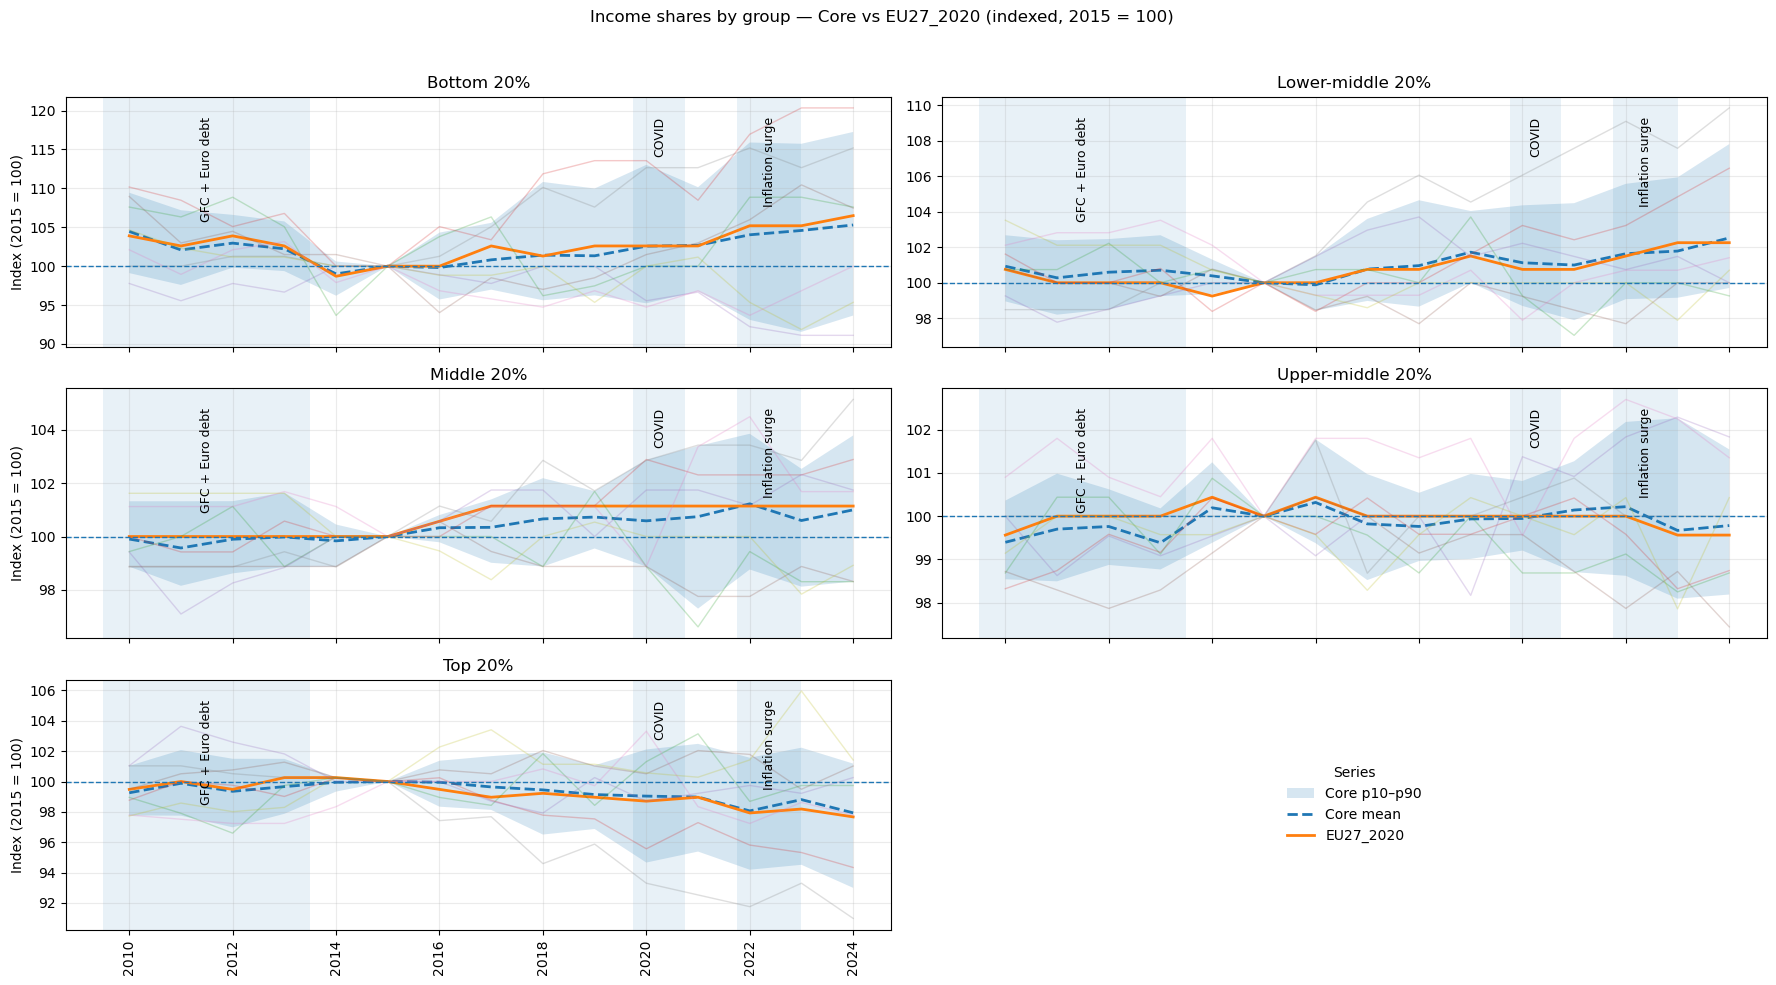

In [41]:
# --- Q4.B  Decile-only core drivers plot (robust) ---

# REQUIREMENT: define ONE of these earlier in your notebook:
# CORE_GEOS = MAJOR_EU_GEOS   (your earlier GDP-relevance set)
# or
# CORE_GEOS = CORE_EA_GEOS    (a euro-core set)
assert "CORE_GEOS" in globals(), "Define CORE_GEOS once (either major economies or euro-core) before running this cell."

# Load panel if needed
df = macro.copy() if "macro" in globals() else pd.read_parquet(DATA_PROCESSED / "master_quarterly_panel.parquet")

# Income SHARE only
income_q = df.loc[
    (df["indic_il"] == "SHARE") & (df["currency"] == "EUR"),
    ["geo", "timeQuarter", "quantile", "incomeValue"]
].copy()

income_q["year"] = income_q["timeQuarter"].dt.year

# --- HARD FILTER: deciles only (D1..D10). This avoids accidental P95/P99/etc. mixing.
qstr = income_q["quantile"].astype(str).str.strip()
income_q = income_q.loc[qstr.str.match(r"^D([1-9]|10)$", na=False)].copy()

income_q["qrank"] = qstr.loc[income_q.index].str.extract(r"(\d+)", expand=False).astype(int)

# Deduplicate quarterly repeats -> annual per geo/decile
income_annual = (
    income_q.groupby(["geo", "year", "qrank"], as_index=False)["incomeValue"].mean()
)

# 5 groups from 10 deciles: (D1-2),(D3-4),(D5-6),(D7-8),(D9-10)
def _dgroup20(d):
    if d in [1, 2]:   return "Bottom 20%"
    if d in [3, 4]:   return "Lower-middle 20%"
    if d in [5, 6]:   return "Middle 20%"
    if d in [7, 8]:   return "Upper-middle 20%"
    if d in [9, 10]:  return "Top 20%"
    return pd.NA

income_annual["group5"] = income_annual["qrank"].map(_dgroup20)

grouped = (
    income_annual.dropna(subset=["group5"])
    .groupby(["geo", "year", "group5"], as_index=False)["incomeValue"]
    .sum()
    .rename(columns={"incomeValue": "share_raw"})
)

# Quality: sums should be ~100 (or sometimes ~1000). Infer scale from decile-only totals.
chk = grouped.groupby(["geo", "year"], as_index=False)["share_raw"].sum().rename(columns={"share_raw": "sum_all"})
median_sum = float(chk.loc[chk["sum_all"] > 0, "sum_all"].median())
scale = 1000 if median_sum > 200 else 100

grouped = grouped.merge(chk, on=["geo", "year"], how="left")
grouped["sum_pct"] = grouped["sum_all"] * (100 / scale)
grouped = grouped.loc[(grouped["sum_all"] > 0) & grouped["sum_pct"].between(98, 102)].copy()

grouped["share_pct"] = grouped["share_raw"] * (100 / scale)
grouped = grouped.loc[grouped["year"].between(2010, 2024)].copy()

# Index to 2015=100 within each geo/group
base = grouped.loc[grouped["year"] == 2015, ["geo", "group5", "share_pct"]].rename(columns={"share_pct": "base_share"})
g = grouped.merge(base, on=["geo", "group5"], how="left")
g["share_index"] = 100 * (g["share_pct"] / g["base_share"])

core = g.loc[g["geo"].isin(CORE_GEOS)].copy()
eu27 = g.loc[g["geo"] == "EU27_2020"].copy()

def _pctl(s, p):
    s = pd.to_numeric(s, errors="coerce").dropna()
    return np.nanpercentile(s, p) if len(s) >= 3 else np.nan

core_summ = (
    core.groupby(["year", "group5"], as_index=False)
    .agg(
        core_mean=("share_index", lambda s: pd.to_numeric(s, errors="coerce").mean()),
        core_p10=("share_index", lambda s: _pctl(s, 10)),
        core_p90=("share_index", lambda s: _pctl(s, 90)),
        n_core=("share_index", "count"),
    )
)

eu27_line = eu27[["year", "group5", "share_index"]].rename(columns={"share_index": "eu27_index"})
plot_df = core_summ.merge(eu27_line, on=["year", "group5"], how="left")

CRISES = [
    ("GFC + Euro debt", 2009.5, 2013.5),
    ("COVID", 2019.75, 2020.75),
    ("Inflation surge", 2021.75, 2023.0),
]
groups_order = ["Bottom 20%", "Lower-middle 20%", "Middle 20%", "Upper-middle 20%", "Top 20%"]

fig, axes = plt.subplots(3, 2, figsize=(18, 10), sharex=True)
axes = axes.flatten()

for i, grp in enumerate(groups_order):
    ax = axes[i]
    df_grp = plot_df.loc[plot_df["group5"] == grp].sort_values("year")

    for label, x0, x1 in CRISES:
        ax.axvspan(x0, x1, alpha=0.10)
        ax.text((x0 + x1) / 2, 0.92, label, rotation=90, va="top", ha="center",
                transform=ax.get_xaxis_transform(), fontsize=9)

    x   = df_grp["year"].to_numpy(dtype=float)
    p10 = df_grp["core_p10"].to_numpy(dtype=float)
    p90 = df_grp["core_p90"].to_numpy(dtype=float)
    mu  = df_grp["core_mean"].to_numpy(dtype=float)
    eu  = df_grp["eu27_index"].to_numpy(dtype=float)

    m_band = np.isfinite(x) & np.isfinite(p10) & np.isfinite(p90)
    m_line = np.isfinite(x) & np.isfinite(mu)
    m_eu   = np.isfinite(x) & np.isfinite(eu)

    ax.fill_between(x[m_band], p10[m_band], p90[m_band], alpha=0.18, label="Core p10–p90")
    ax.plot(x[m_line], mu[m_line], linestyle="--", linewidth=2, label="Core mean")
    ax.plot(x[m_eu], eu[m_eu], linewidth=2, label="EU27_2020")

    # Thin core-country lines (drivers)
    core_grp = core.loc[core["group5"] == grp].copy()
    for geo, dgeo in core_grp.groupby("geo"):
        dgeo = dgeo.sort_values("year")
        ax.plot(dgeo["year"].to_numpy(), pd.to_numeric(dgeo["share_index"], errors="coerce").to_numpy(),
                linewidth=1, alpha=0.25)

    ax.axhline(100, linestyle="--", linewidth=1)
    ax.set_title(grp)
    ax.grid(True, alpha=0.25)
    if i % 2 == 0:
        ax.set_ylabel("Index (2015 = 100)")

# Legend panel
axes[5].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
axes[5].legend(handles[:3], labels[:3], title="Series", loc="center", frameon=False)

# X ticks every 2 years, vertical
for ax in axes[:5]:
    ax.set_xticks(list(range(2010, 2025, 2)))
    for t in ax.get_xticklabels():
        t.set_rotation(90)

fig.suptitle("Income shares by group — Core vs EU27_2020 (indexed, 2015 = 100)", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])

outpath = FIGURES_DIR / "income_core_drivers_core_vs_eu27_3x2.png"
fig.savefig(outpath, dpi=200, bbox_inches="tight")
print("Saved figure to:", outpath)

plt.show()


In [42]:
# --- Save figure: income_core_drivers_lines_core_vs_eu27_3x2.png ---

outpath = FIGURES_DIR / "income_core_drivers_lines_core_vs_eu27_3x2.png"
fig.savefig(outpath, dpi=200, bbox_inches="tight")
print("Saved figure to:", outpath)


Saved figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/income_core_drivers_lines_core_vs_eu27_3x2.png




This figure decomposes the Core-vs-EU27 comparison by showing **Core-country trajectories** for each income group (thin lines), alongside:
- **Core mean (dashed)**: average indexed change across the selected core European countries.
- **Core p10–p90 band (shaded)**: the middle 80% of Core-country outcomes (10th to 90th percentile), capturing **cross-country dispersion** within the core group.
- **EU27_2020 (solid)**: the EU aggregate benchmark.

All series are **indexed to 2015 = 100**, so values show *relative changes in income shares* since 2015, not levels.

**How to read it**
- When the **EU27 line tracks the Core mean**, the aggregate is broadly aligned with core-country dynamics for that group.
- When the **shaded band widens**, core countries are diverging — the “core” is not behaving as a single block.
- Thin-line outliers indicate **which countries drive dispersion** in a given period (especially around the shaded crisis windows).

This “drivers” view complements the cleaner summary plot (Q4.A): Q4.A answers *what the core vs EU27 pattern is*, while Q4.B shows *which specific countries create that pattern*.


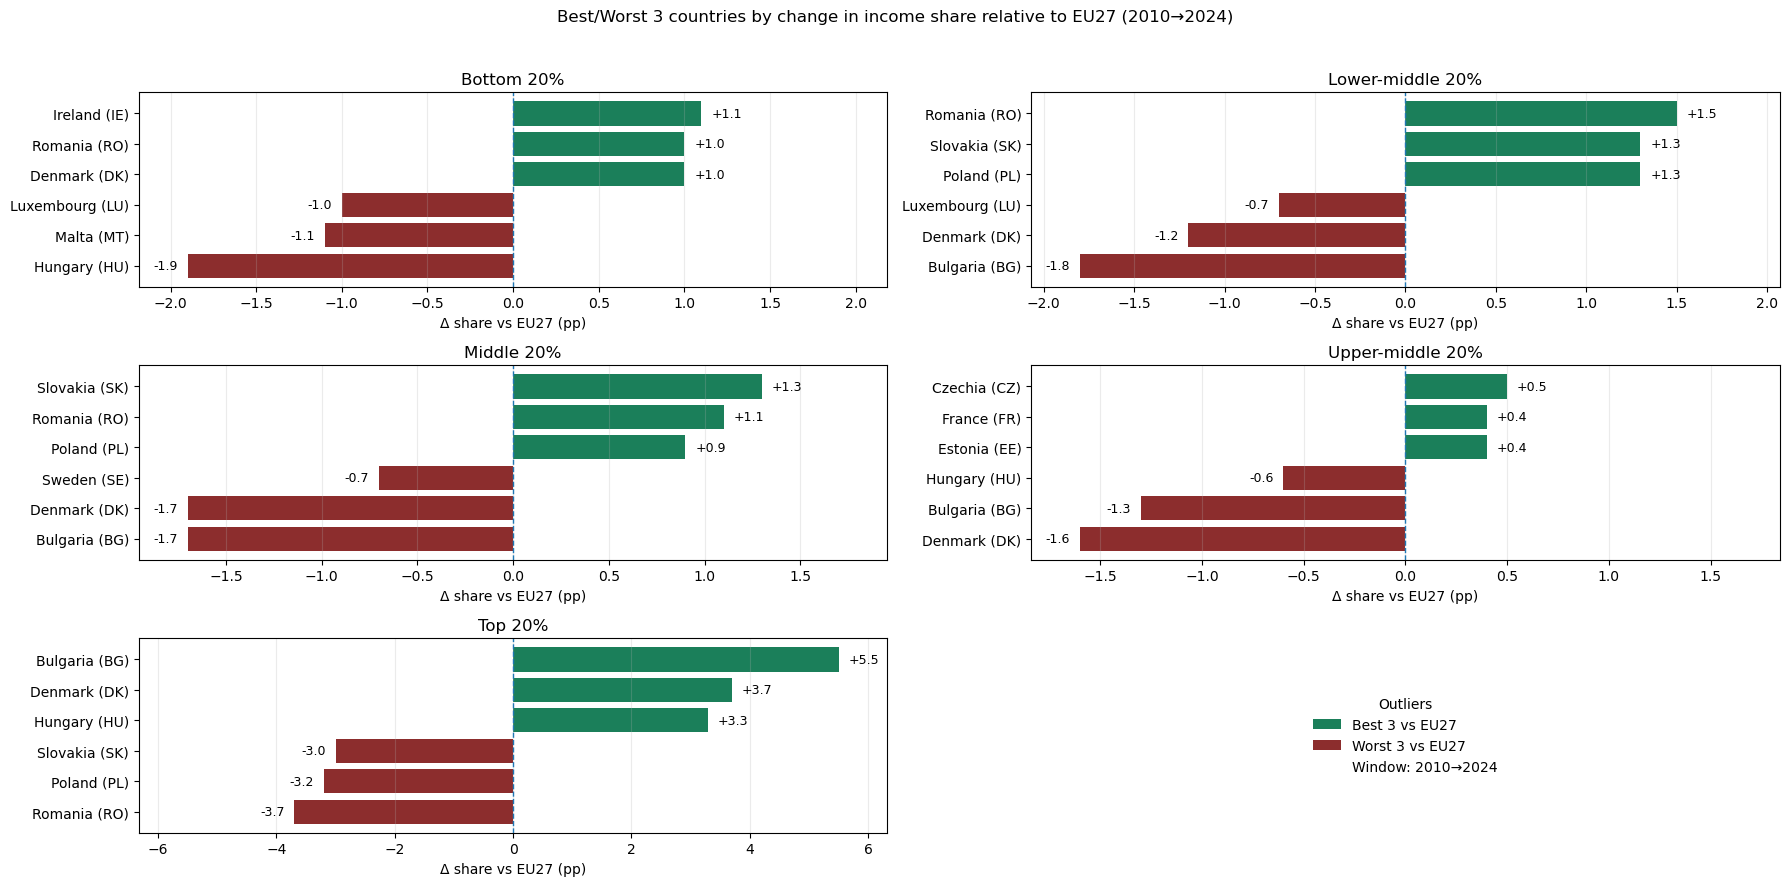

In [43]:
# --- Q4.C2 Outliers: Best/Worst 3 vs EU27 (robust to empty/NaN years) ---

START_YEAR, END_YEAR = 2010, 2024
GROUPS_ORDER = ["Bottom 20%", "Lower-middle 20%", "Middle 20%", "Upper-middle 20%", "Top 20%"]

# --- Geo label mapping (code -> human name) ---
from src.config import GEO_LABELS_FILE
geo_labels = pd.read_csv(GEO_LABELS_FILE)
geo_name_map = dict(zip(geo_labels["geo"], geo_labels["geo_label"]))

def _nice_geo(geo: str, width: int = 26) -> str:
    name = geo_name_map.get(geo, geo)
    lab = f"{name} ({geo})" if name != geo else str(geo)
    return textwrap.shorten(lab, width=width, placeholder="…")

# --- 1) Guardrails: grouped must exist and have needed columns ---
req = {"geo", "year", "group5", "share_pct"}
missing = req - set(grouped.columns)
if missing:
    raise ValueError(f"`grouped` is missing columns: {missing}. Available: {list(grouped.columns)}")

g2 = grouped.copy()

# Coerce year safely -> drop NaN -> int
g2["year"] = pd.to_numeric(g2["year"], errors="coerce")
g2 = g2.dropna(subset=["geo", "year", "group5", "share_pct"]).copy()
g2["year"] = g2["year"].round(0).astype(int)

# --- 2) Pivot to endpoints and compute Δ share (pp) ---
wide = g2.pivot_table(
    index=["geo", "group5"],
    columns="year",
    values="share_pct",
    aggfunc="mean"
)

wide.columns = wide.columns.astype(int)
available_years = sorted(wide.columns.tolist())

start_y = START_YEAR if START_YEAR in wide.columns else min(available_years)
end_y   = END_YEAR   if END_YEAR   in wide.columns else max(available_years)

wide2 = wide.dropna(subset=[start_y, end_y]).copy()
delta = (wide2[end_y] - wide2[start_y]).rename("delta_pp").reset_index()

# --- 3) EU27 benchmark per group ---
eu = (
    delta.loc[delta["geo"] == "EU27_2020", ["group5", "delta_pp"]]
    .rename(columns={"delta_pp": "eu27_delta_pp"})
)

delta = delta.merge(eu, on="group5", how="left")
delta["rel_vs_eu27_pp"] = delta["delta_pp"] - delta["eu27_delta_pp"]

delta = delta.loc[delta["geo"] != "EU27_2020"].copy()

# --- 4) Pick Best/Worst 3 per group ---
rows = []
for grp in GROUPS_ORDER:
    d = delta.loc[delta["group5"] == grp].dropna(subset=["rel_vs_eu27_pp"]).copy()
    best = d.nlargest(3, "rel_vs_eu27_pp").assign(bucket="Best 3")
    worst = d.nsmallest(3, "rel_vs_eu27_pp").assign(bucket="Worst 3")
    rows.append(pd.concat([worst, best], ignore_index=True))

out = pd.concat(rows, ignore_index=True)
out["geo_label"] = out["geo"].map(_nice_geo)

# --- 5) Plot: 3x2 grid (last cell = legend) ---
fig, axes = plt.subplots(3, 2, figsize=(18, 9))
axes = axes.flatten()

# Gentle, meaningful colors
COLOR_BEST = "#1B7F5A"   # deep muted green
COLOR_WORST = "#8C2D2D"  # deep muted red

for i, grp in enumerate(GROUPS_ORDER):
    ax = axes[i]
    d = out.loc[out["group5"] == grp].sort_values("rel_vs_eu27_pp")

    colors = np.where(d["bucket"].eq("Best 3"), COLOR_BEST, COLOR_WORST)
    bars = ax.barh(d["geo_label"], d["rel_vs_eu27_pp"], color=colors)

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(grp)
    ax.set_xlabel("Δ share vs EU27 (pp)")
    ax.grid(axis="x", alpha=0.25)

    max_abs = float(np.nanmax(np.abs(d["rel_vs_eu27_pp"].values))) if len(d) else 1.0
    max_abs = max(max_abs, 0.5)
    ax.set_xlim(-1.15 * max_abs, 1.15 * max_abs)

    for b in bars:
        v = b.get_width()
        y = b.get_y() + b.get_height() / 2
        ha = "left" if v >= 0 else "right"
        x = v + (0.03 * max_abs if v >= 0 else -0.03 * max_abs)
        ax.text(x, y, f"{v:+.1f}", va="center", ha=ha, fontsize=9)

# Legend cell
axes[5].axis("off")
handles = [
    Patch(facecolor=COLOR_BEST, label="Best 3 vs EU27"),
    Patch(facecolor=COLOR_WORST, label="Worst 3 vs EU27"),
    Patch(facecolor="none", edgecolor="none", label=f"Window: {start_y}→{end_y}"),
]
axes[5].legend(handles=handles, loc="center", frameon=False, title="Outliers")

fig.suptitle(
    f"Best/Worst 3 countries by change in income share relative to EU27 ({start_y}→{end_y})",
    y=0.98
)
fig.tight_layout(rect=[0, 0, 1, 0.96])

outpath = FIGURES_DIR / f"income_outliers_best_worst_vs_eu27_3x2_{start_y}_{end_y}.png"
fig.savefig(outpath, dpi=200, bbox_inches="tight")
plt.show()

**Best/Worst 3 countries by change in income share **relative to EU27** (2010 → 2024)**

This figure highlights which countries experienced the largest *distributional shifts* **compared with the EU27 aggregate trend**.

What is plotted

- For each income group (Bottom 20% … Top 20%), we compute each country's change in income share (percentage points) from 2010 to 2024.
- We compute the same change for **EU27_2020**, then plot the **difference vs EU27**:

$$
\Delta^{\mathrm{rel}}_{c,g}
=
\left(
\text{share}_{c,g}^{2024}
-
\text{share}_{c,g}^{2010}
\right)
-
\left(
\text{share}_{\text{EU27},g}^{2024}
-
\text{share}_{\text{EU27},g}^{2010}
\right)
$$

- Bars to the **right (green)** mean that the group’s share rose **more than EU27** in that country.
- Bars to the **left (red)** mean that the group’s share rose **less than EU27** (or fell more).

**How to interpret**

- This is an *outlier finder*: it isolates **country-specific divergence** from the EU-wide trend.
- It does **not** say whether inequality is “good” or “bad” in isolation — only who moved *more or less than the EU benchmark* for each group.

**Why benchmark to EU27**

- EU27 acts as the macro reference path (common shocks + common drift).
- Subtracting it removes EU-wide movement and makes cross-country comparisons more interpretable.

In [44]:
# ============================================================
# Q4.C Crisis-window outliers — SETUP (build `grouped`)
#   - Decile-only (D1..D10) -> 5 groups (Bottom20..Top20)
#   - Annualize (mean across quarters; income is repeated within year)
#   - Strict coverage: keep only geo-years with all 10 deciles & ~100% total
# ============================================================

# ---- Output dirs (keep consistent with your project tree) ----
FIGURES_DIR = REPORTS_DIR / "figures" / "eda_macro"
TABLES_DIR  = REPORTS_DIR / "tables"  / "eda_macro"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# ---- Geo label map (only build once) ----
if "geo_name_map" not in globals():
    geo_labels = pd.read_csv(GEO_LABELS_FILE)
    geo_name_map = dict(zip(geo_labels["geo"], geo_labels["geo_label"]))

# ---- Use already-loaded macro if present, else load once ----
if "macro" in globals():
    df = macro
else:
    df = pd.read_parquet(DATA_PROCESSED / "master_quarterly_panel.parquet")

# ---- Income share block (SHARE only) ----
income_q = df.loc[
    (df["indic_il"] == "SHARE") & (df["currency"] == "EUR"),
    ["geo", "timeQuarter", "quantile", "incomeValue"]
].copy()

# KEY FIX: timeQuarter is Period[Q-DEC] -> use .dt.year (NOT pd.to_datetime)
income_q["year"] = income_q["timeQuarter"].dt.year

# Decile-only filter (avoid mixing other quantiles/percentiles)
q = income_q["quantile"].astype(str).str.strip().str.upper()
is_decile = q.str.fullmatch(r"D(10|[1-9])")
income_q = income_q.loc[is_decile].copy()
income_q["decile"] = q.loc[income_q.index].str.extract(r"(\d+)").astype(int)

# Annualize: mean across quarters (same value repeated, so mean is safe)
annual_dec = (
    income_q.groupby(["geo", "year", "decile"], as_index=False)["incomeValue"]
    .mean()
    .rename(columns={"incomeValue": "dec_share"})
)

# Coverage check: 10 deciles and sums ~100 (or ~1000 depending on scale)
chk = (
    annual_dec.groupby(["geo", "year"], as_index=False)
    .agg(n_deciles=("decile", "nunique"), sum_dec=("dec_share", "sum"))
)

# Infer scale (some sources store 0-1000 instead of 0-100)
median_sum = float(chk.loc[chk["sum_dec"] > 0, "sum_dec"].median())
scale = 1000 if median_sum > 200 else 100

chk["sum_pct"] = chk["sum_dec"] * (100 / scale)
chk["ok"] = (chk["n_deciles"] == 10) & chk["sum_pct"].between(98, 102)

print("OK share of rows:", chk["ok"].mean())
print("Example bad rows:")
display(chk.loc[~chk["ok"]].head(10))

# Keep only valid geo-years
annual_dec = annual_dec.merge(chk[["geo", "year", "ok"]], on=["geo", "year"], how="left")
annual_dec = annual_dec.loc[annual_dec["ok"]].drop(columns=["ok"]).copy()

# Map deciles -> 5 groups (Bottom20..Top20)
def decile_to_group5(d: int) -> str:
    if d in (1, 2):  return "Bottom 20%"
    if d in (3, 4):  return "Lower-middle 20%"
    if d in (5, 6):  return "Middle 20%"
    if d in (7, 8):  return "Upper-middle 20%"
    return "Top 20%"

annual_dec["group5"] = annual_dec["decile"].map(decile_to_group5)

# Aggregate to 5 groups and convert to percent points
grouped = (
    annual_dec.groupby(["geo", "year", "group5"], as_index=False)["dec_share"]
    .sum()
    .rename(columns={"dec_share": "share_sum_raw"})
)

grouped["share_pct"] = grouped["share_sum_raw"] * (100 / scale)
grouped = grouped.drop(columns=["share_sum_raw"])

# Work window where EU27 is reliable (your notebook shows EU27 valid 2010–2024)
grouped = grouped.loc[grouped["year"].between(2010, 2024)].copy()

print(
    "Built `grouped`:", grouped.shape,
    "| years:", grouped["year"].min(), "→", grouped["year"].max(),
    "| geos:", grouped["geo"].nunique(),
    "| inferred scale:", scale
)
display(grouped.head(10))


OK share of rows: 0.7977777777777778
Example bad rows:


,geo,year,n_deciles,sum_dec,sum_pct,ok
2,AT,2002,10,0.0,0.0,False
27,BE,2002,10,0.0,0.0,False
50,BG,2000,10,0.0,0.0,False
51,BG,2001,10,0.0,0.0,False
52,BG,2002,10,0.0,0.0,False
53,BG,2003,10,0.0,0.0,False
54,BG,2004,10,0.0,0.0,False
55,BG,2005,10,0.0,0.0,False
75,CH,2000,10,0.0,0.0,False
76,CH,2001,10,0.0,0.0,False


Built `grouped`: (2585, 4) | years: 2010 → 2024 | geos: 36 | inferred scale: 100


,geo,year,group5,share_pct
45,AT,2010,Bottom 20%,8.6
46,AT,2010,Lower-middle 20%,14.0
47,AT,2010,Middle 20%,17.9
48,AT,2010,Top 20%,37.1
49,AT,2010,Upper-middle 20%,22.4
50,AT,2011,Bottom 20%,8.8
51,AT,2011,Lower-middle 20%,14.0
52,AT,2011,Middle 20%,18.0
53,AT,2011,Top 20%,36.4
54,AT,2011,Upper-middle 20%,22.8


In [45]:
# ============================================================
# Helpers: outlier table + 3x2 plot with safe spacing
# ============================================================

GROUPS_ORDER = ["Bottom 20%", "Lower-middle 20%", "Middle 20%", "Upper-middle 20%", "Top 20%"]
EU_GEO = "EU27_2020"
TOP_N = 3

COLOR_BEST  = "#1B7F5A"
COLOR_WORST = "#8C2D2D"

def build_outliers_table(grouped_df, start_y, end_y, compare="eu27", top_n=3):
    """
    Returns: out_tbl with Best/Worst per group5
    compare:
      - "eu27": score = (Δpp_country - Δpp_EU27)  [divergence]
      - "absolute": score = Δpp_country           [pure change]
    """
    w = grouped_df.pivot_table(
        index=["geo", "group5"], columns="year", values="share_pct", aggfunc="mean"
    )

    if start_y not in w.columns or end_y not in w.columns:
        avail = sorted([int(c) for c in w.columns.tolist()])
        raise ValueError(f"Missing endpoints {start_y} or {end_y}. Available years: {avail[:5]} ... {avail[-5:]}")

    d = (w[end_y] - w[start_y]).rename("delta_pp").reset_index()

    if compare == "eu27":
        eu = d.loc[d["geo"] == EU_GEO, ["group5", "delta_pp"]].rename(columns={"delta_pp": "eu27_delta_pp"})
        d = d.merge(eu, on="group5", how="left")
        d["score"] = d["delta_pp"] - d["eu27_delta_pp"]
        score_col = "score"
        xlabel = "Δ share vs EU27 (pp)"
    elif compare == "absolute":
        d["score"] = d["delta_pp"]
        score_col = "score"
        xlabel = f"Δ income share (pp), {start_y}→{end_y}"
    else:
        raise ValueError("compare must be 'eu27' or 'absolute'")

    # label names
    d["geo_label"] = d["geo"].map(lambda g: f"{geo_name_map.get(g, g)} ({g})")

    # drop EU itself from competition
    d = d.loc[d["geo"] != EU_GEO].copy()

    rows = []
    for g in GROUPS_ORDER:
        sub = d.loc[d["group5"] == g].dropna(subset=[score_col])
        if sub.empty:
            continue
        best  = sub.nlargest(top_n, score_col).assign(outlier=f"Best {top_n}")
        worst = sub.nsmallest(top_n, score_col).assign(outlier=f"Worst {top_n}")
        rows.append(pd.concat([best, worst], ignore_index=True))

    out = pd.concat(rows, ignore_index=True) if rows else d.iloc[0:0].copy()
    out["start_year"] = start_y
    out["end_year"] = end_y
    out.rename(columns={score_col: "value"}, inplace=True)  # unified plot col
    return out, xlabel


def plot_outliers_3x2(out_tbl, title, xlabel, outpath_png):
    # 5 panels + 1 legend cell
    fig, axes = plt.subplots(3, 2, figsize=(18, 9))
    axes = axes.flatten()

    for i, grp in enumerate(GROUPS_ORDER):
        ax = axes[i]
        d = out_tbl.loc[out_tbl["group5"] == grp].sort_values("value")

        colors = np.where(d["outlier"].str.contains("Best"), COLOR_BEST, COLOR_WORST)
        bars = ax.barh(d["geo_label"], d["value"], color=colors)

        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_title(grp)
        ax.set_xlabel(xlabel)
        ax.grid(axis="x", alpha=0.25)

        # Expand x-limits to prevent text clipping on both sides
        max_abs = float(np.nanmax(np.abs(d["value"].values))) if len(d) else 1.0
        max_abs = max(max_abs, 0.5)
        ax.set_xlim(-1.30 * max_abs, 1.30 * max_abs)

        # Value labels with safe padding (and not clipped)
        for b in bars:
            v = b.get_width()
            y = b.get_y() + b.get_height() / 2
            ha = "left" if v >= 0 else "right"
            x = v + (0.04 * max_abs if v >= 0 else -0.04 * max_abs)
            ax.text(x, y, f"{v:+.1f}", va="center", ha=ha, fontsize=9, clip_on=False)

    # legend cell
    axes[5].axis("off")
    handles = [
        Patch(facecolor=COLOR_BEST,  label="Best 3"),
        Patch(facecolor=COLOR_WORST, label="Worst 3"),
    ]
    axes[5].legend(handles=handles, loc="center", frameon=False, title="Outliers")

    fig.suptitle(title, y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(outpath_png, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved figure to:", outpath_png)


Saved table to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_macro/income_outliers_vs_eu27_gfc_eurodebt_2010_2013.csv


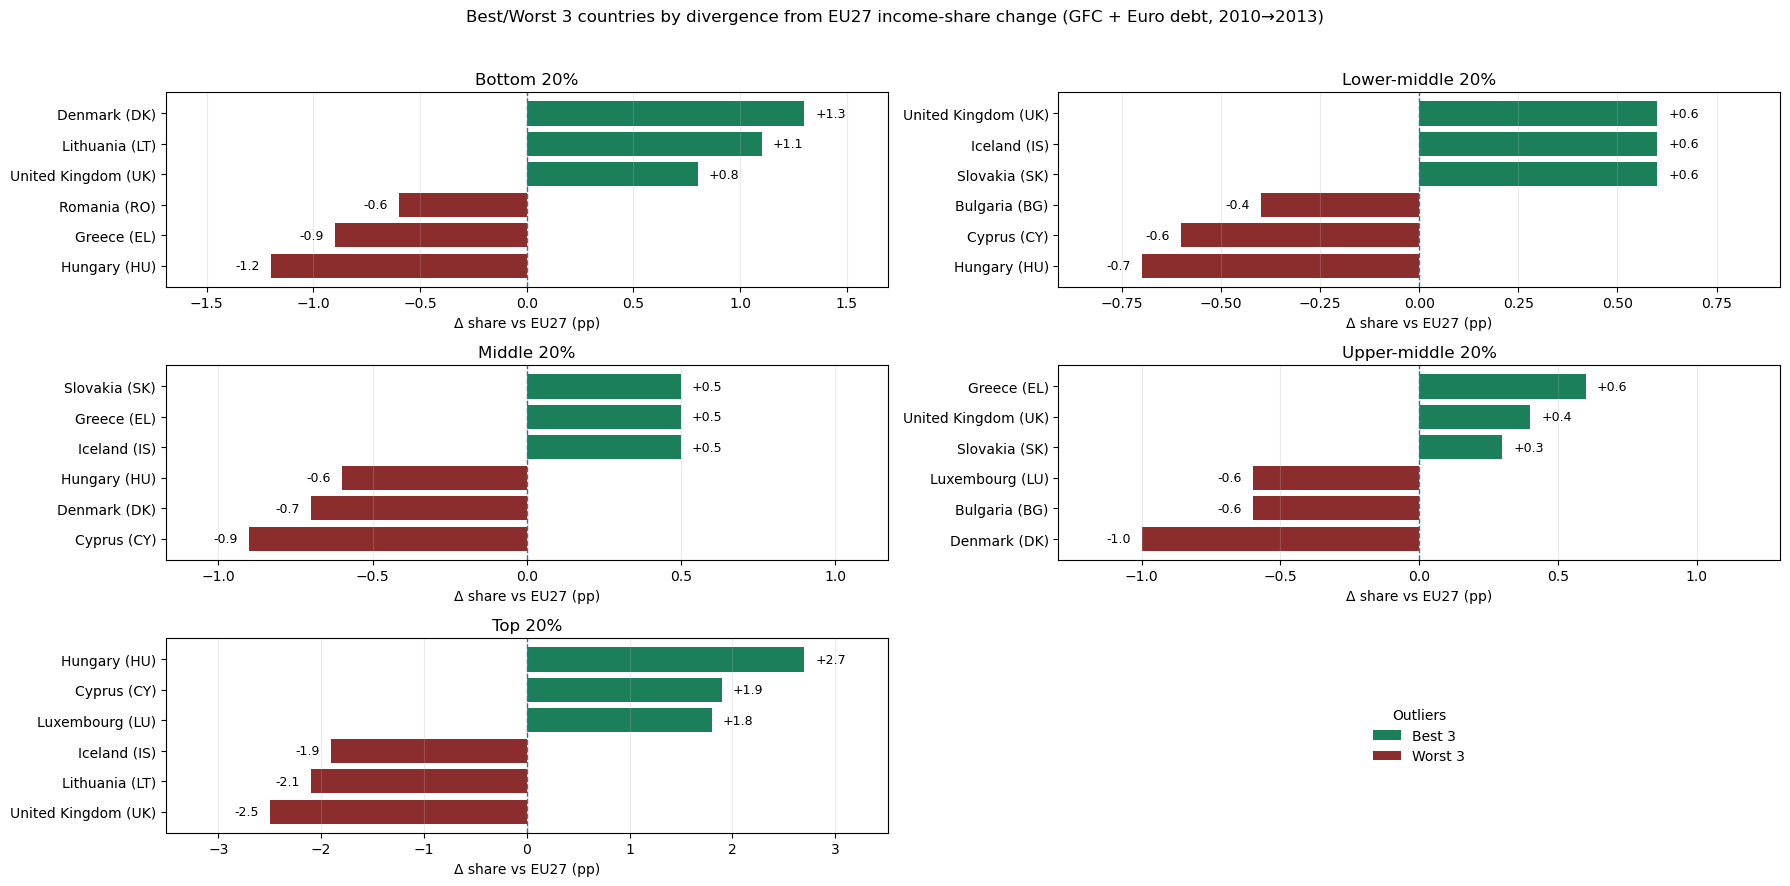

Saved figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/income_outliers_best_worst_vs_eu27_gfc_eurodebt_2010_2013.png
Saved table to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_macro/income_outliers_vs_eu27_covid_2019_2021.csv


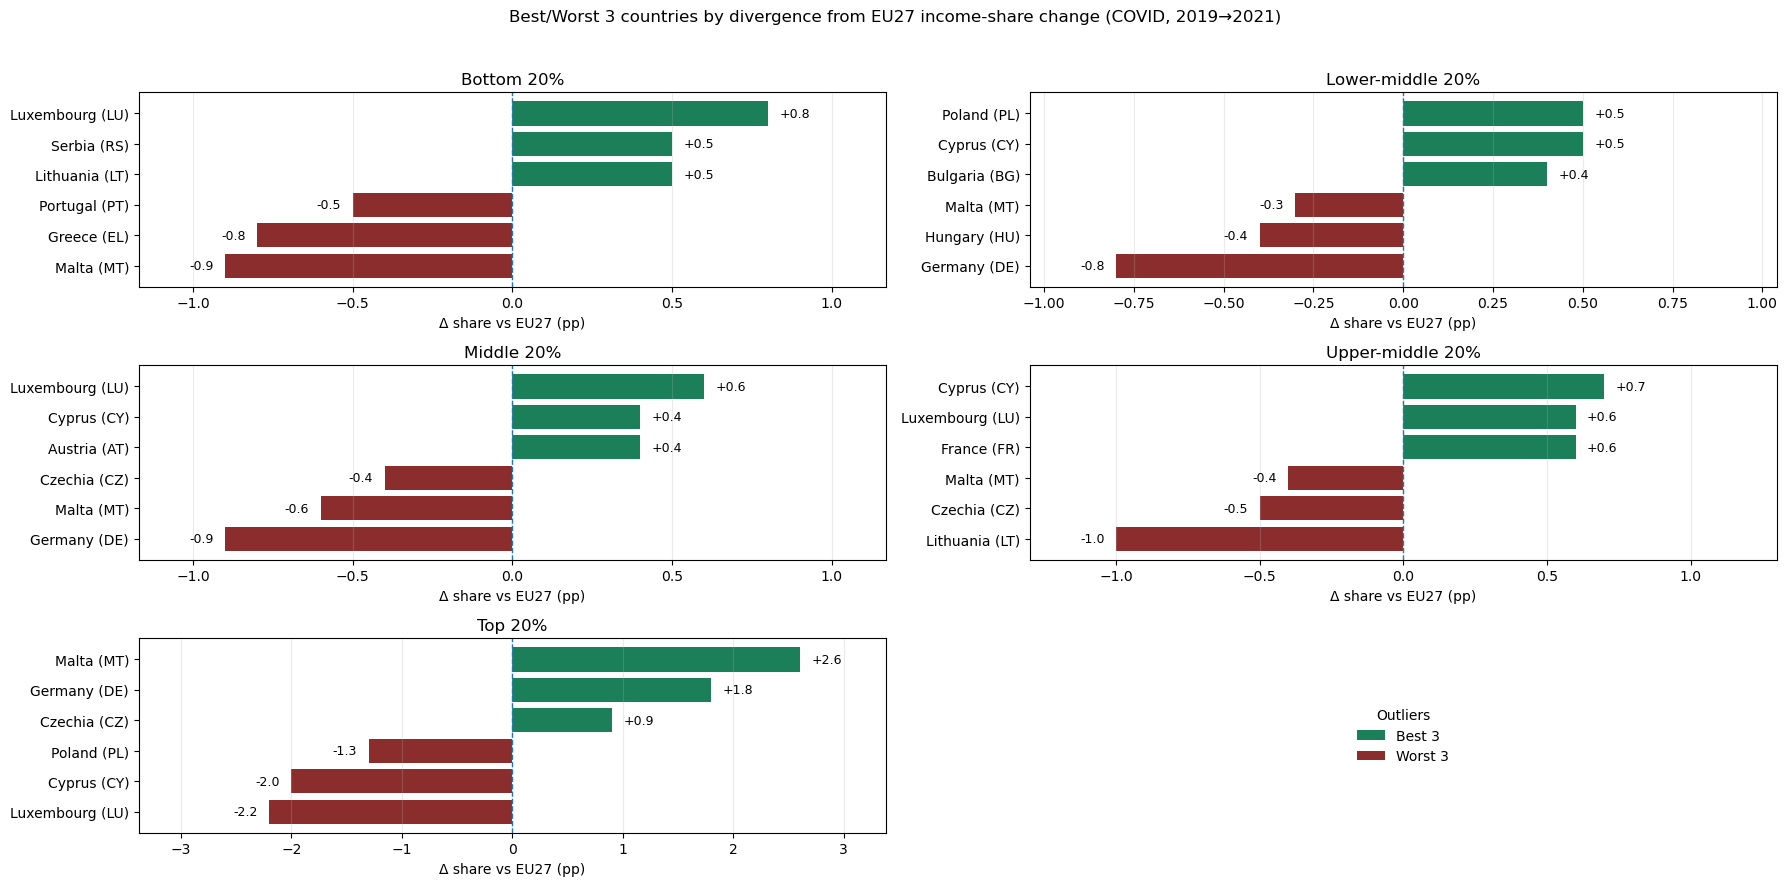

Saved figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/income_outliers_best_worst_vs_eu27_covid_2019_2021.png
Saved table to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_macro/income_outliers_vs_eu27_inflation_surge_2021_2024.csv


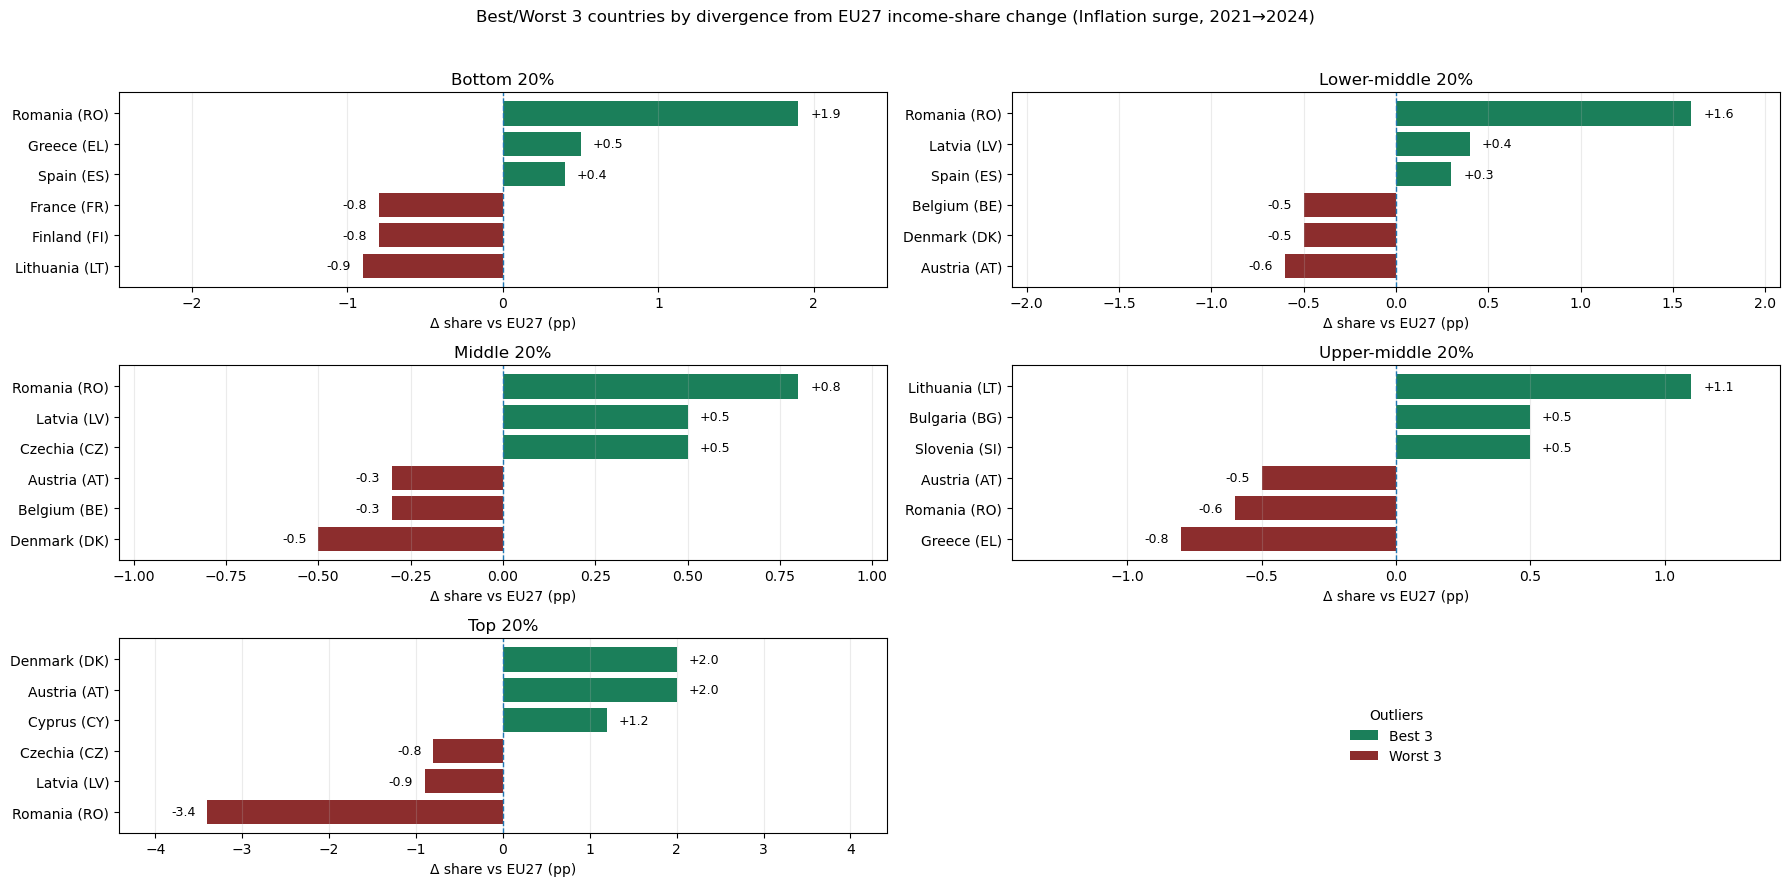

Saved figure to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_macro/income_outliers_best_worst_vs_eu27_inflation_surge_2021_2024.png
Saved combined table: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_macro/income_outliers_vs_eu27_ALL_WINDOWS.csv


,geo,group5,delta_pp,eu27_delta_pp,value,geo_label,outlier,start_year,end_year,window,window_slug
0,DK,Bottom 20%,1.2,-0.1,1.3,Denmark (DK),Best 3,2010,2013,GFC + Euro debt,gfc_eurodebt
1,LT,Bottom 20%,1.0,-0.1,1.1,Lithuania (LT),Best 3,2010,2013,GFC + Euro debt,gfc_eurodebt
2,UK,Bottom 20%,0.7,-0.1,0.8,United Kingdom (UK),Best 3,2010,2013,GFC + Euro debt,gfc_eurodebt
3,HU,Bottom 20%,-1.3,-0.1,-1.2,Hungary (HU),Worst 3,2010,2013,GFC + Euro debt,gfc_eurodebt
4,EL,Bottom 20%,-1.0,-0.1,-0.9,Greece (EL),Worst 3,2010,2013,GFC + Euro debt,gfc_eurodebt
5,RO,Bottom 20%,-0.7,-0.1,-0.6,Romania (RO),Worst 3,2010,2013,GFC + Euro debt,gfc_eurodebt
6,IS,Lower-middle 20%,0.5,-0.1,0.6,Iceland (IS),Best 3,2010,2013,GFC + Euro debt,gfc_eurodebt
7,UK,Lower-middle 20%,0.5,-0.1,0.6,United Kingdom (UK),Best 3,2010,2013,GFC + Euro debt,gfc_eurodebt
8,SK,Lower-middle 20%,0.5,-0.1,0.6,Slovakia (SK),Best 3,2010,2013,GFC + Euro debt,gfc_eurodebt
9,HU,Lower-middle 20%,-0.8,-0.1,-0.7,Hungary (HU),Worst 3,2010,2013,GFC + Euro debt,gfc_eurodebt


In [46]:
# ============================================================
# Run crisis windows (Top 3 / Worst 3 per group) + save outputs
# ============================================================

CRISIS_WINDOWS = [
    ("gfc_eurodebt",     "GFC + Euro debt",    2010, 2013),
    ("covid",            "COVID",             2019, 2021),
    ("inflation_surge",  "Inflation surge",   2021, 2024),
]

all_outliers = []

for slug, label, y0, y1 in CRISIS_WINDOWS:
    # --- divergence vs EU27 (recommended for crisis comparison) ---
    out_tbl, xlabel = build_outliers_table(grouped, y0, y1, compare="eu27", top_n=TOP_N)

    if out_tbl.empty:
        print(f"[SKIP] {label} {y0}→{y1} (no data after coverage filters)")
        continue

    out_tbl["window"] = label
    out_tbl["window_slug"] = slug

    # Save table
    csv_path = TABLES_DIR / f"income_outliers_vs_eu27_{slug}_{y0}_{y1}.csv"
    out_tbl.to_csv(csv_path, index=False)

    # Parquet is optional (depends on pyarrow/fastparquet)
    try:
        pq_path = TABLES_DIR / f"income_outliers_vs_eu27_{slug}_{y0}_{y1}.parquet"
        out_tbl.to_parquet(pq_path, index=False)
    except Exception as e:
        print("Parquet save failed (CSV is saved):", e)

    print("Saved table to:", csv_path)

    # Save figure
    png_path = FIGURES_DIR / f"income_outliers_best_worst_vs_eu27_{slug}_{y0}_{y1}.png"
    plot_outliers_3x2(
        out_tbl,
        title=f"Best/Worst 3 countries by divergence from EU27 income-share change ({label}, {y0}→{y1})",
        xlabel=xlabel,
        outpath_png=png_path
    )

    all_outliers.append(out_tbl)

# Combined table across all windows (handy for appendix / QA)
if all_outliers:
    out_all = pd.concat(all_outliers, ignore_index=True)
    out_all.to_csv(TABLES_DIR / "income_outliers_vs_eu27_ALL_WINDOWS.csv", index=False)
    print("Saved combined table:",
          TABLES_DIR / "income_outliers_vs_eu27_ALL_WINDOWS.csv")
    display(out_all.head(20))
